# Forecasting Experiments — Univariado Mensal

Notebook central de experimentos de forecasting mensal.  
Todas as abordagens (data-centric, model-centric e baselines modernos) vivem aqui.

```
projeto/
├── forecasting_experiments.ipynb   ← você está aqui
├── data/                           ← dados brutos e processados
└── outputs/                        ← artefatos, métricas e plots
```

---
## 1. Ambiente do Notebook

Este bloco centraliza tudo o que o restante do notebook precisa para rodar de forma previsível: imports, configuração global, caminhos, seed e inicialização da camada de visualização.

A lógica original foi preservada. A reorganização abaixo tem apenas objetivo estrutural: facilitar leitura, manutenção e navegação entre as etapas do experimento.


In [50]:
# Imports Centralizados
# Todos os imports de nível de notebook ficam aqui para facilitar inspeção,
# reprodução do ambiente e manutenção do pipeline.

import functools
import importlib
import itertools
import json as _json
import json as _json_eval
import random
import time
import warnings
import warnings as _warnings_cv
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import tensorflow as tf
import viz
from scipy.special import inv_boxcox
from scipy.stats import boxcox
from sklearn.preprocessing import RobustScaler, StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow import keras
from tensorflow.keras import layers as KL
from xgboost import XGBRegressor


In [51]:
# Configuração Central e Inicialização do Ambiente

# Reprodutibilidade
SEED = 42

# Horizonte de teste (número de períodos mensais)
TEST_HORIZON = 12

# Janela sazonal — padrão 12 para série mensal; edite se usar outra periodicidade
SEASONAL_PERIOD = 12

# Número de lags explícitos no pipeline Data-Centric (padrão = SEASONAL_PERIOD)
DC_WINDOW = SEASONAL_PERIOD

# Caminhos (relativos ao notebook; pathlib resolve o absoluto)
ROOT        = Path('.').resolve()
DATA_PATH   = ROOT / 'data'
OUTPUT_PATH = ROOT / 'outputs'

# Nome do experimento — usado em logs e artefatos salvos
EXP_NAME = 'baseline_run_v1'

# Configuração da Base
FILE_NAME  = 'Base_DBP.xlsx'  # nome do arquivo dentro de data/  (.csv | .xlsx | .xls)
DATE_COL   = 'data'           # nome da coluna de datas no arquivo original
VALUE_COL  = 'valores'        # nome da coluna de valores no arquivo original

# Garantir que os diretórios existam
DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(f'ROOT            : {ROOT}')
print(f'DATA_PATH       : {DATA_PATH}')
print(f'OUTPUT_PATH     : {OUTPUT_PATH}')
print(f'EXP_NAME        : {EXP_NAME}')
print(f'TEST_HORIZON    : {TEST_HORIZON} meses | SEED: {SEED}')
print(f'SEASONAL_PERIOD : {SEASONAL_PERIOD} | DC_WINDOW: {DC_WINDOW}')
print(f"Arquivo         : {FILE_NAME}  |  date='{DATE_COL}'  value='{VALUE_COL}'")

# Inicialização global do ambiente
warnings.filterwarnings('ignore')
random.seed(SEED)
np.random.seed(SEED)
viz.set_figure_dir(str(OUTPUT_PATH / 'figures'))


ROOT            : C:\Users\lucas\bracis2\projeto - Copia
DATA_PATH       : C:\Users\lucas\bracis2\projeto - Copia\data
OUTPUT_PATH     : C:\Users\lucas\bracis2\projeto - Copia\outputs
EXP_NAME        : baseline_run_v1
TEST_HORIZON    : 12 meses | SEED: 42
SEASONAL_PERIOD : 12 | DC_WINDOW: 12
Arquivo         : Base_DBP.xlsx  |  date='data'  value='valores'


### 1.1 Utilitários Centrais

Funções reutilizáveis que sustentam os dois pipelines do notebook.
Este bloco concentra reprodutibilidade, transformações, escalonamento,
criação de janelas temporais e checagens anti-leakage.

> Regra de ouro: nenhum `fit` usa dados fora do treino.


In [52]:
# ── Utilitários Centrais ──────────────────────────────────────────────────────


# ─── 1. Reprodutibilidade ─────────────────────────────────────────────────────

def set_global_seed(seed: int) -> None:
    """
    Fixa seeds em todas as bibliotecas relevantes do pipeline.

    Parâmetros
    ----------
    seed : int
        Valor da seed global.

    Garantia
    --------
    Cobre random, numpy e, quando disponíveis, torch e tensorflow.
    Deve ser chamada antes de qualquer operação aleatória do pipeline.
    """
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


# ─── 2. Box-Cox ───────────────────────────────────────────────────────────────

def fit_boxcox_on_train(
    series_train: pd.Series,
) -> tuple[pd.Series, dict]:
    """
    Estima o lambda de Box-Cox exclusivamente nos dados de treino.

    Parâmetros
    ----------
    series_train : pd.Series
        Série de treino. Pode conter zeros ou negativos; um shift mínimo
        é aplicado automaticamente para garantir positividade.

    Retorna
    -------
    transformed : pd.Series
        Série de treino na escala Box-Cox (mesmo índice de entrada).
    fitted_params : dict
        {'lambda': float, 'shift': float}
        Necessário para transform_boxcox e inverse_boxcox.

    Garantia anti-leakage
    ---------------------
    O lambda é estimado SOMENTE em series_train.
    Nunca passe dados de teste ou a série completa aqui.
    """
    shift = 0.0
    if series_train.min() <= 0:
        shift = abs(series_train.min()) + 1e-6

    shifted = series_train + shift
    transformed_values, lam = boxcox(shifted.values)

    fitted_params = {"lambda": float(lam), "shift": float(shift)}
    transformed = pd.Series(
        transformed_values, index=series_train.index, name=series_train.name
    )
    return transformed, fitted_params


def transform_boxcox(series: pd.Series, fitted_params: dict) -> pd.Series:
    """
    Aplica Box-Cox com parâmetros pré-fittados (sem re-estimar o lambda).

    Parâmetros
    ----------
    series        : pd.Series — série a transformar (treino ou teste).
    fitted_params : dict      — saída de fit_boxcox_on_train.

    Retorna
    -------
    pd.Series com valores transformados e mesmo índice de entrada.

    Garantia anti-leakage
    ---------------------
    Usa o lambda fittado no treino; não aprende nada novo dos dados recebidos.
    Seguro para aplicar sobre o conjunto de teste.
    """
    lam   = fitted_params["lambda"]
    shift = fitted_params["shift"]
    shifted = series + shift

    if lam == 0:
        transformed = np.log(shifted.values)
    else:
        transformed = (shifted.values ** lam - 1) / lam

    return pd.Series(transformed, index=series.index, name=series.name)


def inverse_boxcox(
    values: "np.ndarray | pd.Series",
    fitted_params: dict,
) -> np.ndarray:
    """
    Inverte a transformação Box-Cox, devolvendo valores na escala original.

    Parâmetros
    ----------
    values        : array-like — valores na escala transformada (ex.: previsões).
    fitted_params : dict       — saída de fit_boxcox_on_train.

    Retorna
    -------
    np.ndarray na escala original (shift removido).
    """
    lam   = fitted_params["lambda"]
    shift = fitted_params["shift"]
    return inv_boxcox(np.asarray(values, dtype=float), lam) - shift


# ─── 3. Escalonamento ────────────────────────────────────────────────────────

def fit_scaler_on_train(
    X_train: np.ndarray,
    y_train: "np.ndarray | None" = None,
) -> tuple[StandardScaler, "StandardScaler | None"]:
    """
    Fita escaladores StandardScaler SOMENTE nos dados de treino.

    Parâmetros
    ----------
    X_train : np.ndarray, shape (n, p) — features de treino.
    y_train : np.ndarray | None        — target de treino 1-D; opcional.

    Retorna
    -------
    scaler_X : StandardScaler fittado em X_train.
    scaler_y : StandardScaler fittado em y_train, ou None se não fornecido.

    Garantia anti-leakage
    ---------------------
    Nenhum dado externo ao treino participa do fit.
    Use transform_with_fitted_scaler para transformar treino E teste
    sem re-fitar.
    """
    scaler_X = StandardScaler()
    scaler_X.fit(X_train)

    scaler_y = None
    if y_train is not None:
        scaler_y = StandardScaler()
        scaler_y.fit(y_train.reshape(-1, 1))

    return scaler_X, scaler_y


def transform_with_fitted_scaler(
    X: np.ndarray,
    scaler: StandardScaler,
    inverse: bool = False,
) -> np.ndarray:
    """
    Aplica (ou inverte) transformação com escalonador já fittado.

    Parâmetros
    ----------
    X       : np.ndarray — dados a transformar (features ou target).
    scaler  : StandardScaler — fittado via fit_scaler_on_train.
    inverse : bool — se True, inverte (útil para previsões na escala original).

    Retorna
    -------
    np.ndarray transformado ou invertido.

    Garantia anti-leakage
    ---------------------
    Apenas aplica média/std já calculadas no treino; não re-fita.
    """
    arr = np.asarray(X, dtype=float)
    if inverse:
        return scaler.inverse_transform(arr.reshape(-1, 1)).ravel()
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return scaler.transform(arr)


# ─── 4. Janelas Temporais ────────────────────────────────────────────────────

def make_last_window(series: pd.Series, window_size: int) -> np.ndarray:
    """
    Extrai as últimas `window_size` observações de uma série para uso
    como janela de entrada em inferência (pós-treino).

    Parâmetros
    ----------
    series      : pd.Series — série de treino (já transformada, se necessário).
    window_size : int       — número de lags a incluir.

    Retorna
    -------
    np.ndarray shape (window_size,) sem qualquer informação futura.

    Garantia anti-leakage
    ---------------------
    Usa somente as últimas observações da série passada.
    Não acessa dados além do índice fornecido.
    """
    if len(series) < window_size:
        raise ValueError(
            f"Série tem {len(series)} obs., mas window_size={window_size}. "
            "Reduza window_size ou forneça mais dados de treino."
        )
    return series.values[-window_size:].copy()


# ─── 5. Reshape para LSTM ────────────────────────────────────────────────────

def to_lstm_3d(X: np.ndarray) -> np.ndarray:
    """
    Converte array 2-D (samples, features) para 3-D (samples, timesteps=1, features),
    formato exigido por camadas LSTM do Keras / PyTorch.

    Parâmetros
    ----------
    X : np.ndarray shape (n_samples, n_features)

    Retorna
    -------
    np.ndarray shape (n_samples, 1, n_features)

    Nota
    ----
    Cada sample é tratado como um único timestep.
    Para múltiplos timesteps, construa X com shape
    (n_samples, n_timesteps, n_features) antes de chamar esta função.
    """
    if X.ndim != 2:
        raise ValueError(
            f"X deve ser 2-D (samples, features); recebido shape {X.shape}."
        )
    return X[:, np.newaxis, :]


# ─── 6. Checagens Anti-Leakage ───────────────────────────────────────────────

def assert_no_future_information(
    train_end_date: pd.Timestamp,
    feature_dates: pd.DatetimeIndex,
    label: str = "feature",
) -> None:
    """
    Garante que nenhuma data das features ultrapassa o fim do treino.

    Parâmetros
    ----------
    train_end_date : pd.Timestamp     — último timestamp do treino.
    feature_dates  : pd.DatetimeIndex — índice de datas das features a checar.
    label          : str              — nome descritivo (usado na mensagem de erro).

    Levanta
    -------
    AssertionError se qualquer data em feature_dates > train_end_date.
    """
    future_mask = feature_dates > train_end_date
    if future_mask.any():
        n = int(future_mask.sum())
        first_future = feature_dates[future_mask][0]
        raise AssertionError(
            f"[LEAKAGE] '{label}': {n} data(s) posterior(es) ao fim do treino "
            f"({train_end_date.date()}). Primeira data futura: {first_future.date()}."
        )


def assert_temporal_alignment(
    index_a: pd.DatetimeIndex,
    index_b: pd.DatetimeIndex,
    label_a: str = "A",
    label_b: str = "B",
) -> None:
    """
    Verifica se dois índices temporais estão perfeitamente alinhados
    (mesmo comprimento e mesmas datas na mesma ordem).

    Parâmetros
    ----------
    index_a : pd.DatetimeIndex
    index_b : pd.DatetimeIndex
    label_a : str — nome descritivo do primeiro índice (para mensagem de erro).
    label_b : str — nome descritivo do segundo índice (para mensagem de erro).

    Levanta
    -------
    AssertionError se os índices diferirem em comprimento ou em datas.
    """
    if len(index_a) != len(index_b):
        raise AssertionError(
            f"[ALINHAMENTO] '{label_a}' tem {len(index_a)} obs., "
            f"'{label_b}' tem {len(index_b)}."
        )
    if not (index_a == index_b).all():
        mismatches = int((index_a != index_b).sum())
        raise AssertionError(
            f"[ALINHAMENTO] '{label_a}' e '{label_b}' têm {mismatches} "
            "data(s) divergente(s). Verifique ordenação e frequência."
        )


# ─── Aplicar seed global imediatamente ───────────────────────────────────────
set_global_seed(SEED)
print("Utilitários carregados e seed fixada.")

Utilitários carregados e seed fixada.


### 1.2 Núcleo de Previsão Recursiva

Este bloco reúne as duas rotinas recursivas usadas no experimento, uma para
cada filosofia de pipeline.

| Função | Pipeline | Entrada principal | Transformações |
|---|---|---|---|
| `recursive_forecast_simple` | Model-Centric | `last_window` (array de lags) | Nenhuma — funciona na escala de treino |
| `recursive_forecast_rich` | Data-Centric | `history_bc` (série Box-Cox) | Escala features → prevê → inverte scaler → inverte Box-Cox |

**Princípio:** cada previsão `ŷ_{t+1}` é gerada somente com dados disponíveis até `t`. O histórico cresce a cada passo. Nenhuma linha anterior é reutilizada.


In [53]:
# ── Núcleo de Previsão Recursiva ──────────────────────────────────────────────
#
# Convenção temporal (ambas as funções):
#   last_window[-1] ou history_bc[-1]  =  y_T  (último valor OBSERVADO)
#   preds[0]                           =  ŷ_{T+1}  (primeira previsão)
#   preds[k]                           =  ŷ_{T+1+k}
#
# Tipos de modelo suportados:
#   "xgboost"     → input (1, n_features)              — tabular
#   "lstm"        → input (1, window_size, 1)           — lags como timesteps  [simple]
#   "lstm_simple" → input (1, 1, n_features)            — features como 1 timestep [rich]
#   "lstm_dual"   → [input_seq(1,1,n_seq), input_stat(1,n_stat)]              [rich]


# ─── Helper interno: despacha a previsão para o tipo de modelo ───────────────

def _predict_from_row(
    model,
    x: np.ndarray,
    model_type: str,
    seq_idx: "list[int] | None" = None,
    stat_idx: "list[int] | None" = None,
) -> float:
    """
    Despacha a chamada de inferência de acordo com model_type.

    Parâmetros
    ----------
    model      : modelo com .predict()
    x          : np.ndarray shape (1, n_features) — já escalado
    model_type : "xgboost" | "lstm" | "lstm_simple" | "lstm_dual"
    seq_idx    : índices das colunas sequenciais (somente lstm_dual)
    stat_idx   : índices das colunas estáticas   (somente lstm_dual)

    Retorna
    -------
    float — valor previsto na escala do modelo
    """
    if model_type == "xgboost":
        return float(model.predict(x)[0])

    if model_type == "lstm":
        # Model-Centric: cada lag é um timestep → (1, window_size, 1)
        window_size = x.shape[1]
        return float(model.predict(x.reshape(1, window_size, 1), verbose=0).ravel()[0])

    if model_type == "lstm_simple":
        # Data-Centric simples: todas as features como 1 timestep → (1, 1, n)
        return float(model.predict(to_lstm_3d(x), verbose=0).ravel()[0])

    if model_type == "lstm_dual":
        # Data-Centric dual-input: seq → (1,1,n_seq)  |  stat → (1,n_stat)
        x_seq  = to_lstm_3d(x[:, seq_idx])
        x_stat = x[:, stat_idx]
        return float(model.predict([x_seq, x_stat], verbose=0).ravel()[0])

    raise ValueError(
        f"model_type '{model_type}' não reconhecido. "
        "Válidos: 'xgboost', 'lstm', 'lstm_simple', 'lstm_dual'."
    )


# ─── recursive_forecast_simple ───────────────────────────────────────────────

def recursive_forecast_simple(
    model,
    last_window: np.ndarray,
    horizon: int,
    model_type: str = "xgboost",
) -> np.ndarray:
    """
    Previsão recursiva com lags puros — pipeline Model-Centric.

    A cada passo k:
        1. Recorta os últimos window_size valores do histórico
        2. Prevê ŷ_{T+1+k}
        3. Appende a previsão ao histórico (sliding window natural)

    Parâmetros
    ----------
    model        : modelo treinado com .predict().
                   Treinado sobre features de lags puros.
    last_window  : np.ndarray shape (window_size,)
                   Últimos window_size valores na escala de treino.
                   Origem: make_last_window(train, window_size).
                   O elemento [-1] é y_T.
    horizon      : int — passos à frente
    model_type   : "xgboost" → input (1, window_size)
                   "lstm"    → input (1, window_size, 1)

    Retorna
    -------
    np.ndarray shape (horizon,) na mesma escala de last_window.

    Garantias
    ---------
    - preds[0] = ŷ_{T+1} ; preds[k] = ŷ_{T+1+k}
    - Cada passo recorta o histórico com [-window_size:] — sem reutilizar linhas
    - last_window não é modificado (cópia interna via list())
    """
    _VALID = {"xgboost", "lstm"}
    if model_type not in _VALID:
        raise ValueError(f"model_type deve ser um de {_VALID}; recebido '{model_type}'.")

    window_size = len(last_window)
    history     = list(last_window.astype(float))   # cópia mutável
    preds       = []

    for _ in range(horizon):
        # Recorte explícito: nunca reutiliza a linha anterior
        window = np.array(history[-window_size:], dtype=float).reshape(1, -1)
        pred   = _predict_from_row(model, window, model_type)

        preds.append(pred)
        history.append(pred)   # histórico cresce antes do próximo passo

    return np.array(preds, dtype=float)


# ─── recursive_forecast_rich ─────────────────────────────────────────────────

def recursive_forecast_rich(
    model,
    history_bc: pd.Series,
    horizon: int,
    window: int,
    feature_cols: list[str],
    n_train: int,
    scaler_X: StandardScaler,
    scaler_y: "StandardScaler | None" = None,
    bc_params: "dict | None" = None,
    model_type: str = "xgboost",
    seq_cols: "list[str] | None" = None,
    stat_cols: "list[str] | None" = None,
) -> np.ndarray:
    """
    Previsão recursiva com features ricas causais — pipeline Data-Centric.

    Fluxo por passo k
    ------------------
    1. make_next_step_row(history)  →  x_raw   (Box-Cox, sem scaling)
    2. scaler_X.transform(x_raw)   →  x_sc    (padronizado)
    3. model.predict(x_sc)         →  pred_sc  (escala do modelo)
    4. scaler_y.inverse(pred_sc)   →  pred_bc  (escala Box-Cox)     [se scaler_y]
    5. concat(history, pred_bc)    →  history cresce em 1 mês
    Após o loop:
    6. inverse_boxcox(preds_bc)    →  escala original               [se bc_params]

    Parâmetros
    ----------
    model        : modelo treinado
    history_bc   : pd.Series (DatetimeIndex mensal)
                   Série na escala Box-Cox. last element = y_T.
                   NÃO é modificada (cópia interna).
    horizon      : int — passos à frente
    window       : int — mesmo DC_WINDOW de make_train_matrix
    feature_cols : list[str] — saída de make_train_matrix (contrato de ordem)
    n_train      : int — len(train_bc) original; permanece FIXO durante a recursão
                   para que o trend extrapole linearmente de forma consistente
    scaler_X     : StandardScaler fittado em X_dc.values
    scaler_y     : StandardScaler fittado em y_dc.values
                   None → modelo prevê diretamente em escala Box-Cox
    bc_params    : dict de fit_boxcox_on_train
                   None → retorna na escala Box-Cox (ou raw, se sem Box-Cox)
    model_type   : "xgboost" | "lstm_simple" | "lstm_dual"
    seq_cols     : features sequenciais p/ lstm_dual  (lag_*, diff, ma, std)
    stat_cols    : features estáticas   p/ lstm_dual  (month_sin, month_cos, trend)

    Retorna
    -------
    np.ndarray shape (horizon,)
    Escala original se bc_params fornecido; Box-Cox caso contrário.

    Garantias
    ---------
    - Cada linha construída do zero via make_next_step_row (sem reaproveitamento)
    - history_bc de entrada preservada (cópia interna)
    - n_train fixo → trend consistente ao longo de toda a recursão
    - Falha explícita no passo de features se histórico insuficiente
    """
    _VALID = {"xgboost", "lstm_simple", "lstm_dual"}
    if model_type not in _VALID:
        raise ValueError(f"model_type deve ser {_VALID}; recebido '{model_type}'.")
    if model_type == "lstm_dual" and (seq_cols is None or stat_cols is None):
        raise ValueError("lstm_dual requer seq_cols e stat_cols definidos.")

    # Índices calculados uma única vez, antes do loop
    seq_idx  = [feature_cols.index(c) for c in seq_cols]  if seq_cols  else None
    stat_idx = [feature_cols.index(c) for c in stat_cols] if stat_cols else None

    history  = history_bc.copy()   # cópia interna — não modifica o argumento
    preds_bc = []

    for _ in range(horizon):
        # ── 1. Linha de features do próximo passo (escala Box-Cox, sem scaling)
        x_raw = make_next_step_row(
            history      = history,
            window       = window,
            feature_cols = feature_cols,
            n_train      = n_train,
        )   # shape (1, n_features)

        # ── 2. Escalar com scaler_X fittado somente no treino
        x_sc = transform_with_fitted_scaler(x_raw, scaler_X)

        # ── 3. Inferência (despacha para xgboost / lstm_simple / lstm_dual)
        pred_sc = _predict_from_row(
            model, x_sc, model_type,
            seq_idx=seq_idx, stat_idx=stat_idx,
        )

        # ── 4. Inverter scaling do target → escala Box-Cox
        if scaler_y is not None:
            pred_bc = float(
                transform_with_fitted_scaler(
                    np.array([[pred_sc]]), scaler_y, inverse=True
                ).ravel()[0]
            )
        else:
            pred_bc = float(pred_sc)

        preds_bc.append(pred_bc)

        # ── 5. Avançar histórico: appende pred_bc (Box-Cox) com a data correta
        next_date = history.index[-1] + pd.DateOffset(months=1)
        history   = pd.concat(
            [history, pd.Series([pred_bc], index=pd.DatetimeIndex([next_date]))]
        )

    # ── 6. Inverter Box-Cox → escala original
    preds_arr = np.array(preds_bc, dtype=float)
    return inverse_boxcox(preds_arr, bc_params) if bc_params is not None else preds_arr


# ─── check_forecast_alignment ────────────────────────────────────────────────

def check_forecast_alignment(
    preds: np.ndarray,
    test: pd.Series,
    label: str = "model",
) -> pd.DataFrame:
    """
    Verifica alinhamento temporal entre previsões e ground-truth.

    Parâmetros
    ----------
    preds : np.ndarray shape (horizon,) — previsões na escala original
    test  : pd.Series — conjunto de teste, DatetimeIndex
    label : str — nome do modelo (coluna no DataFrame retornado)

    Retorna
    -------
    pd.DataFrame com colunas ["actual", label], indexado pelas datas de test.
    Use este DataFrame para métricas e plots.

    Levanta
    -------
    AssertionError se len(preds) != len(test).
    """
    if len(preds) != len(test):
        raise AssertionError(
            f"[ALINHAMENTO] '{label}': {len(preds)} previsões "
            f"vs {len(test)} observações reais. "
            "Verifique o horizon e o comprimento do teste."
        )
    return pd.DataFrame(
        {"actual": test.values, label: preds},
        index=test.index,
    )


print("Núcleo de previsão recursiva carregado.")

Núcleo de previsão recursiva carregado.


---
## 2. Carregamento da Base

Nesta etapa o notebook lê a série original, padroniza o índice temporal,
constrói os conjuntos de treino e teste e deixa a base pronta para EDA e modelagem.


In [54]:
# ── Carregamento e Preparação da Série ────────────────────────────────────────

def _load_raw(path: Path) -> pd.DataFrame:
    """Lê Excel ou CSV a partir da extensão do arquivo."""
    ext = path.suffix.lower()
    if ext in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if ext == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Formato não suportado: '{ext}'. Use .csv, .xlsx ou .xls.")


def load_series(
    data_path: Path,
    file_name: str,
    date_col: str,
    value_col: str,
    test_horizon: int,
) -> tuple[pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """
    Carrega o arquivo, padroniza e devolve:
        df       — DataFrame completo com colunas ['ds', 'y']
        series   — pd.Series indexada por ds (série completa)
        train    — série de treino (sem as últimas test_horizon obs.)
        test     — série de teste  (últimas test_horizon obs.)
    """
    file_path = data_path / file_name
    raw = _load_raw(file_path)

    # Padronizar nomes de coluna
    df = raw[[date_col, value_col]].rename(columns={date_col: "ds", value_col: "y"})

    # Converter datas e ordenar
    df["ds"] = pd.to_datetime(df["ds"])
    df = df.sort_values("ds").reset_index(drop=True)

    # Série indexada por data
    series = df.set_index("ds")["y"]

    # Split temporal estrito
    train = series.iloc[:-test_horizon]
    test  = series.iloc[-test_horizon:]

    return df, series, train, test


# ── Executar carregamento ─────────────────────────────────────────────────────
df, series, train, test = load_series(
    data_path    = DATA_PATH,
    file_name    = FILE_NAME,
    date_col     = DATE_COL,
    value_col    = VALUE_COL,
    test_horizon = TEST_HORIZON,
)

print(f"Arquivo         : {FILE_NAME}")
print(f"Período         : {series.index.min().date()}  →  {series.index.max().date()}")
print(f"Observações     : {len(series)}  (treino={len(train)} | teste={len(test)})")
print(f"Seasonal period : {SEASONAL_PERIOD}")
print()
display(df.head())

Arquivo         : Base_DBP.xlsx
Período         : 2003-08-01  →  2024-08-01
Observações     : 253  (treino=241 | teste=12)
Seasonal period : 12



,ds,y
0,2003-08-01,8700.0
1,2003-09-01,8900.0
2,2003-10-01,8900.0
3,2003-11-01,9700.0
4,2003-12-01,16600.0


---
## 3. Análise Exploratória e Decomposição

Seção dedicada à inspeção inicial da série, ao recorte treino/teste e à
visualização da estrutura temporal via decomposição STL.


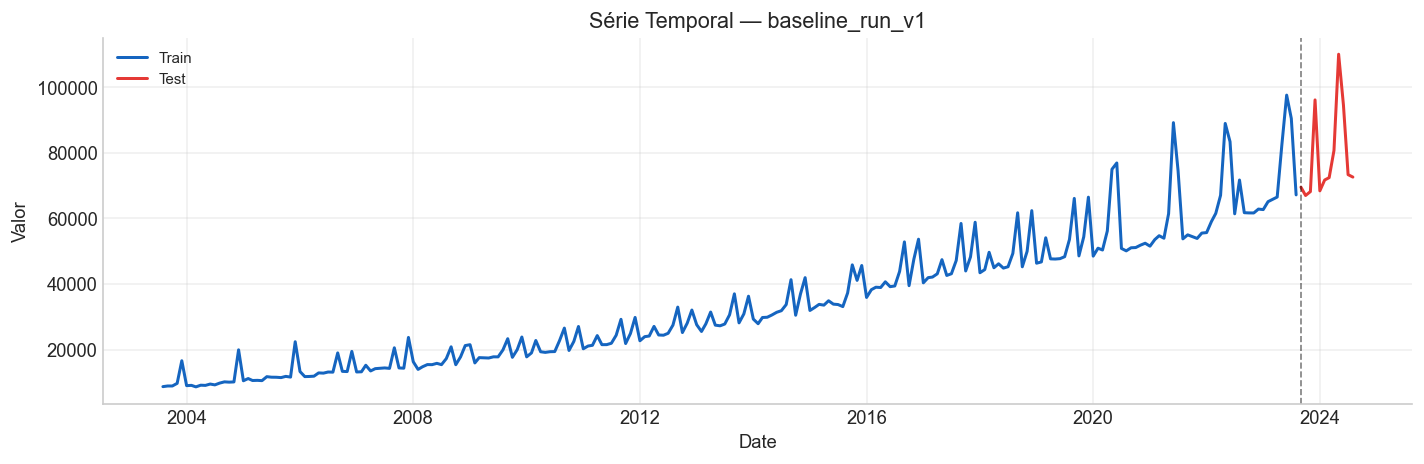

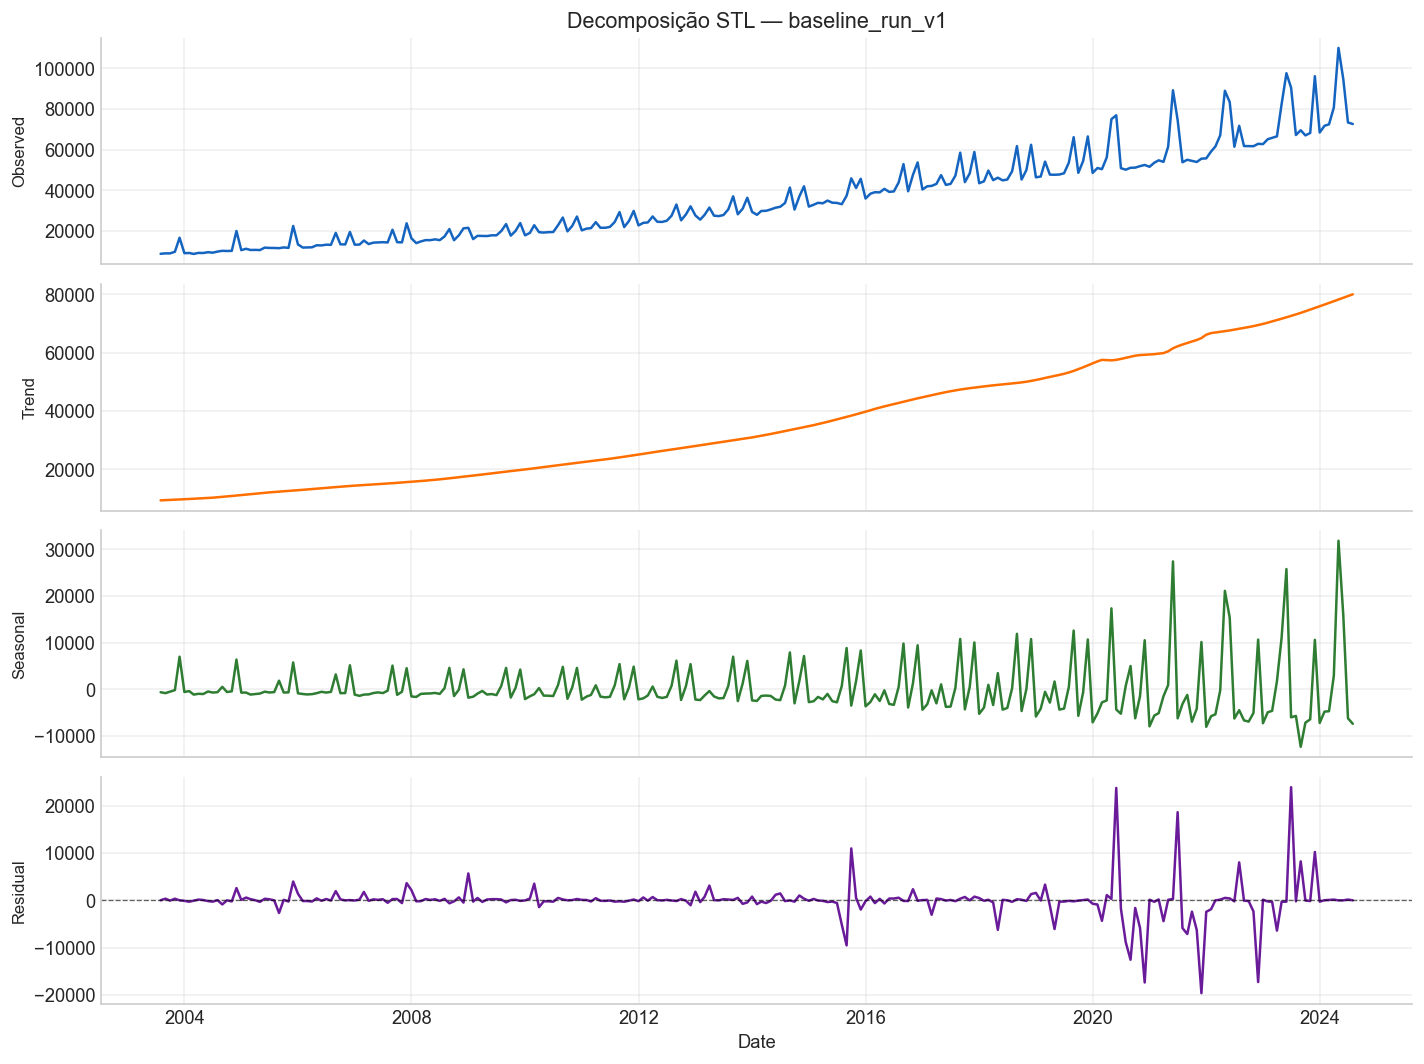

In [55]:
# ── EDA — Série temporal e decomposição ──────────────────────────────────────
# Série com split treino/teste
fig = viz.plot_series(
    series,
    title=f"Série Temporal — {EXP_NAME}",
    ylabel="Valor",
    train=train,
    test=test,
    fname="01_series_split.png",
)
plt.show()

# Decomposição STL (tendência, sazonalidade, resíduo)
fig = viz.plot_stl_decomposition(
    series,
    period=SEASONAL_PERIOD,
    title=f"Decomposição STL — {EXP_NAME}",
    fname="02_stl_decomposition.png",
)
plt.show()


---
## 4. Abordagem Data-Centric

A lógica desta parte permanece a mesma: enriquecer a representação do sinal com
atributos causais, aplicar transformações ajustadas no treino e comparar modelos
simples sobre esse espaço de features.


### 4.1 Feature Engineering — Atributos Causais

**Convenção temporal rigorosa:**
> Linha `t` → prediz `y_t` usando apenas `y_{t-1}, y_{t-2}, …` (shift ≥ 1)

| Grupo | Features | Justificativa |
|---|---|---|
| G1 | `lag_1 … lag_w` | Memória explícita — base AR |
| G2 | `diff_saz_12` | `y_{t-1} − y_{t-13}` — crescimento inter-anual causal |
| G3 | `ma_3`, `ma_12` | Nível curto/médio prazo — sem tocar em `y_t` |
| G4 | `std_12` | Volatilidade local dos 12 meses anteriores |
| G5 | `month_sin`, `month_cos` | Calendário — determinístico, 100% causal |
| G6 | `trend` | Deriva linear normalizada |

In [56]:
# ── make_dc_features ─────────────────────────────────────────────────────────
#
# Partição de colunas para LSTM dual-input:
#   seq_cols  = lag_* + diff_saz_12 + ma_3 + ma_12 + std_12   (temporais)
#   stat_cols = month_sin + month_cos + trend                   (estáticas)

def make_dc_features(series: pd.Series, window: int = 12) -> pd.DataFrame:
    """
    Constrói a matriz de features Data-Centric a partir de uma série univariada.

    Nenhuma coluna depende de y_t — linha t prediz y_t usando y_{t-1}, y_{t-2}, …

    Parâmetros
    ----------
    series : pd.Series, indexada por DatetimeIndex — série transformada (ex.: Box-Cox)
    window : int — número de lags explícitos (lag_1 … lag_window)

    Features geradas
    ----------------
    lag_1…lag_w   y_{t-k}                memória explícita
    diff_saz_12   y_{t-1} − y_{t-13}     crescimento inter-anual causal
    ma_3          mean(y_{t-1..t-3})      nível curto prazo
    ma_12         mean(y_{t-1..t-12})     nível sazonal
    std_12        std(y_{t-1..t-12})      volatilidade local
    month_sin     sin(2π·mês_t/12)        sazonalidade cíclica
    month_cos     cos(2π·mês_t/12)        sazonalidade cíclica (par)
    trend         índice normalizado       deriva linear
    """
    s     = series.copy()
    feats = pd.DataFrame(index=s.index)

    for k in range(1, window + 1):
        feats[f"lag_{k}"] = s.shift(k)

    feats["diff_saz_12"] = s.shift(1) - s.shift(13)

    s1 = s.shift(1)
    feats["ma_3"]   = s1.rolling(3,  min_periods=3).mean()
    feats["ma_12"]  = s1.rolling(12, min_periods=12).mean()
    feats["std_12"] = s1.rolling(12, min_periods=12).std()

    month = s.index.month
    feats["month_sin"] = np.sin(2 * np.pi * month / 12)
    feats["month_cos"] = np.cos(2 * np.pi * month / 12)

    n = len(s)
    feats["trend"] = np.arange(n) / max(n - 1, 1)

    return feats


print("make_dc_features carregada.")

make_dc_features carregada.


In [57]:
# ── make_train_matrix e make_next_step_row ───────────────────────────────────

def make_train_matrix(
    series: pd.Series,
    window: int = 12,
) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    """
    Monta a matriz de treino (X, y) a partir da série de treino transformada.

    Remove o burn-in dos lags/rolling via dropna e executa checagens anti-leakage.

    Parâmetros
    ----------
    series : pd.Series
        Série de TREINO na escala transformada (ex.: saída de fit_boxcox_on_train).
        Nunca passe a série completa ou dados de teste.
    window : int, default 12
        Número de lags — repassado para make_dc_features.

    Retorna
    -------
    X            : pd.DataFrame — features sem NaN, indexadas por DatetimeIndex.
    y            : pd.Series    — target y_t alinhado com X (mesmos índices).
    feature_cols : list[str]    — ordem canônica das colunas; usar como contrato
                                  em make_next_step_row e no escalonador.

    Garantias anti-leakage
    ----------------------
    1. assert_no_future_information: nenhuma data de X ultrapassa o fim do treino.
    2. assert_temporal_alignment: X e y têm exatamente os mesmos índices.
    """
    feats    = make_dc_features(series, window=window)
    combined = feats.assign(__target__=series.values).dropna()

    y = combined.pop("__target__")
    X = combined

    assert_no_future_information(
        train_end_date=series.index[-1],
        feature_dates=X.index,
        label="make_train_matrix → X",
    )
    assert_temporal_alignment(X.index, y.index, label_a="X", label_b="y")

    return X, y, list(X.columns)


def make_next_step_row(
    history: pd.Series,
    window: int,
    feature_cols: list[str],
    n_train: int,
) -> np.ndarray:
    """
    Constrói a linha de features para prever y_{T+1}, dado o histórico até y_T.

    Replica exatamente a semântica de make_dc_features para inferência recursiva:
    - lag_k     = y_{T-(k-1)}           ↔  shift(k)  na linha T+1 do treino
    - diff_saz  = y_T − y_{T-12}        ↔  shift(1) − shift(13)
    - ma_3      = mean(y_T, …, y_{T-2}) ↔  shift(1).rolling(3).mean()
    - ma_12     = mean(y_T, …,y_{T-11}) ↔  shift(1).rolling(12).mean()
    - std_12    = std(y_T, …, y_{T-11}) ↔  shift(1).rolling(12).std()
    - month_sin/cos: mês de T+1 (avança 1 mês no calendário)
    - trend     : posição de T+1 normalizada pelo mesmo denominador do treino

    Parâmetros
    ----------
    history      : pd.Series
        Histórico observado até T (transformado), DatetimeIndex mensal.
        O último elemento é y_T.
        Em inferência recursiva: appende a previsão e re-chame a função.
    window       : int
        Mesmo window usado em make_train_matrix.
    feature_cols : list[str]
        Saída de make_train_matrix — garante alinhamento de ordem e seleção.
    n_train      : int
        len(série de treino original). Mantém fixo ao longo da recursão
        para normalização consistente do trend.

    Retorna
    -------
    np.ndarray shape (1, len(feature_cols)) — pronto para model.predict().

    Levanta
    -------
    ValueError  se history tiver obs. insuficientes.
    KeyError    se feature_cols contiver nome desconhecido (falha cedo).
    """
    min_obs = max(window, 13)   # lags precisam de window obs; diff_saz precisa de 13
    if len(history) < min_obs:
        raise ValueError(
            f"Histórico insuficiente: mínimo {min_obs} obs., "
            f"recebido {len(history)}."
        )

    vals: np.ndarray = history.values.astype(float)
    row: dict[str, float] = {}

    # G1 — Lags: lag_k = y_T, y_{T-1}, …
    for k in range(1, window + 1):
        row[f"lag_{k}"] = float(vals[-k])

    # G2 — Diferença sazonal causal: y_T − y_{T-12}
    #       vals[-1]=y_T, vals[-13]=y_{T-12}
    row["diff_saz_12"] = float(vals[-1] - vals[-13])

    # G3 — Médias móveis (janela cobre [y_T, y_{T-1}, …, y_{T-w+1}])
    row["ma_3"]  = float(np.mean(vals[-3:]))
    row["ma_12"] = float(np.mean(vals[-12:]))

    # G4 — Volatilidade local (ddof=1 consistente com pandas rolling)
    row["std_12"] = float(np.std(vals[-12:], ddof=1))

    # G5 — Calendário: mês de T+1
    next_month = history.index[-1].month % 12 + 1   # 12 → 1, demais +1
    row["month_sin"] = float(np.sin(2 * np.pi * next_month / 12))
    row["month_cos"] = float(np.cos(2 * np.pi * next_month / 12))

    # G6 — Tendência: posição de T+1 normalizada pelo denominador fixo do treino
    #       na linha T+1 do DataFrame de treino hipotético:
    #       trend = (n_train + steps_ahead) / max(n_train - 1, 1)
    next_pos = len(history)   # 0-based: treino tinha posições 0…n_train-1
    row["trend"] = float(next_pos / max(n_train - 1, 1))

    # Ordenar e selecionar conforme contrato de feature_cols
    try:
        ordered = np.array([row[col] for col in feature_cols], dtype=float)
    except KeyError as exc:
        raise KeyError(
            f"make_next_step_row: feature '{exc}' ausente no dicionário. "
            "Verifique se window e feature_cols são consistentes."
        ) from exc

    return ordered.reshape(1, -1)

In [58]:
# ── Referência de execução (descomentar após rodar Seção 2) ──────────────────
#
# 1. Transformação Box-Cox (fit apenas no treino)
# train_bc, bc_params = fit_boxcox_on_train(train)
#
# 2. Matriz de treino
# X_dc, y_dc, dc_feature_cols = make_train_matrix(train_bc, window=DC_WINDOW)
# print(f"X_dc: {X_dc.shape}  |  features: {dc_feature_cols}")
#
# 3. Partição de colunas para LSTM dual-input (referência Seção 5)
# seq_cols  = [c for c in dc_feature_cols
#              if c not in ("month_sin", "month_cos", "trend")]
# stat_cols = ["month_sin", "month_cos", "trend"]
#
# 4. Linha do próximo passo após o treino (primeiro ponto do teste)
# row_t1 = make_next_step_row(
#     history      = train_bc,
#     window       = DC_WINDOW,
#     feature_cols = dc_feature_cols,
#     n_train      = len(train_bc),
# )
# print(f"row_t1 shape: {row_t1.shape}")   # esperado: (1, DC_WINDOW + 7)
#
# 5. Previsão recursiva — esqueleto
# history_bc = train_bc.copy()
# preds_bc   = []
# for step in range(TEST_HORIZON):
#     x_row  = make_next_step_row(history_bc, DC_WINDOW, dc_feature_cols, len(train_bc))
#     pred   = model.predict(x_row)[0]          # na escala Box-Cox
#     preds_bc.append(pred)
#     next_date    = history_bc.index[-1] + pd.DateOffset(months=1)
#     history_bc   = pd.concat([history_bc, pd.Series([pred], index=[next_date])])
# preds_original = inverse_boxcox(np.array(preds_bc), bc_params)

n_features_dc = DC_WINDOW + 7
print("Feature engineering Data-Centric pronto.")
print(f"  Lags : lag_1 … lag_{DC_WINDOW}")
print(f"  Outras: diff_saz_12 | ma_3 | ma_12 | std_12 | month_sin | month_cos | trend")
print(f"  Total : {n_features_dc} features")

Feature engineering Data-Centric pronto.
  Lags : lag_1 … lag_12
  Outras: diff_saz_12 | ma_3 | ma_12 | std_12 | month_sin | month_cos | trend
  Total : 19 features


### 4.2 Pipeline Data-Centric — Preparação, Treinamento e Previsão

Aqui o notebook consolida o pipeline Data-Centric completo: preparação do treino,
ajuste dos modelos, previsão recursiva no horizonte holdout e persistência dos
artefatos principais.

| Modelo | Filosofia | Transformação |
|---|---|---|
| SARIMA (1,1,1)(1,1,1,12) | Referência estatística clássica | Box-Cox |
| XGBoost default | Tabular, lags + features ricas | Box-Cox + StandardScaler |
| LSTM dual-input | Seq (lags+extras) + Static (calendário) | Box-Cox + StandardScaler |


In [59]:
# ── Funções de suporte: preparação, métricas e artefatos ─────────────────────

def prepare_dc_pipeline(
    train: pd.Series,
    window: int = 12,
) -> dict:
    """
    Centraliza todos os passos de preparação Data-Centric a partir do treino.

    Ordem de operações (sem leakage):
        1. fit_boxcox_on_train(train)         → lambda estimado SOMENTE no treino
        2. make_train_matrix(train_bc)        → X_dc, y_dc, feature_cols
        3. fit_scaler_on_train(X_dc, y_dc)   → scaler fittado SOMENTE no treino
        4. Particionar feature_cols           → seq_cols (temporais), stat_cols (estáticas)

    Parâmetros
    ----------
    train  : pd.Series — série de treino na escala original
    window : int       — número de lags (DC_WINDOW)

    Retorna
    -------
    dict com chaves:
        train_bc, bc_params,
        X_dc, y_dc, X_dc_sc, y_dc_sc,
        scaler_X, scaler_y,
        feature_cols, seq_cols, stat_cols, n_train
    """
    # 1. Box-Cox — fit no treino
    train_bc, bc_params = fit_boxcox_on_train(train)

    # 2. Feature matrix
    X_dc, y_dc, feature_cols = make_train_matrix(train_bc, window=window)

    # 3. Scaler — fit no treino
    scaler_X, scaler_y = fit_scaler_on_train(X_dc.values, y_dc.values)
    X_dc_sc = transform_with_fitted_scaler(X_dc.values, scaler_X)
    y_dc_sc = transform_with_fitted_scaler(y_dc.values, scaler_y).ravel()

    # 4. Partição de colunas para LSTM dual-input
    stat_cols = ["month_sin", "month_cos", "trend"]
    seq_cols  = [c for c in feature_cols if c not in stat_cols]

    return {
        "train_bc"    : train_bc,
        "bc_params"   : bc_params,
        "X_dc"        : X_dc,
        "y_dc"        : y_dc,
        "X_dc_sc"     : X_dc_sc,
        "y_dc_sc"     : y_dc_sc,
        "scaler_X"    : scaler_X,
        "scaler_y"    : scaler_y,
        "feature_cols": feature_cols,
        "seq_cols"    : seq_cols,
        "stat_cols"   : stat_cols,
        "n_train"     : len(train_bc),
    }


def compute_metrics(
    actual: np.ndarray,
    predicted: np.ndarray,
    train_actual: np.ndarray,
    label: str = "model",
    m: int = 12,
) -> dict:
    """
    Calcula MAE, RMSE, MASE sazonal e sMAPE na escala original.

    Parâmetros
    ----------
    actual       : ground-truth do conjunto de teste
    predicted    : previsões na escala original
    train_actual : série de treino na escala original (denominador do MASE)
    label        : nome do modelo
    m            : periodicidade sazonal para o MASE (default 12)
    """
    a = np.asarray(actual,    dtype=float)
    p = np.asarray(predicted, dtype=float)

    mae  = float(np.mean(np.abs(a - p)))
    rmse = float(np.sqrt(np.mean((a - p) ** 2)))

    # MASE sazonal: denominador = MAE do Naive Sazonal no treino
    tr = np.asarray(train_actual, dtype=float)
    if len(tr) > m:
        naive_mae = float(np.mean(np.abs(tr[m:] - tr[:-m])))
        mase = mae / max(naive_mae, 1e-8)
    else:
        mase = float("nan")

    # sMAPE (simétrico, em %)
    smape = 100.0 * float(
        np.mean(2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + 1e-8))
    )

    return {
        "model": label,
        "MAE"  : round(mae,   4),
        "RMSE" : round(rmse,  4),
        "MASE" : round(mase,  4),
        "sMAPE": round(smape, 4),
    }


def save_dc_artifacts(
    label: str,
    preds: np.ndarray,
    metrics: dict,
    params: dict,
    test_index: pd.DatetimeIndex,
    output_path: Path,
    exp_name: str,
) -> None:
    """
    Salva previsões (CSV) e métricas + hiperparâmetros (JSON) em output_path.

    Arquivos gerados
    ----------------
    {exp_name}_{label}_preds.csv       — previsões indexadas por data
    {exp_name}_{label}_artifacts.json  — métricas + params efetivos
    """
    # Artefatos em arquivo removidos — resultados exibidos diretamente no notebook.
    pass

In [60]:
# ── SARIMA Data-Centric ────────────────────────────────────────────────────────
#
# Configuração fixa: SARIMA(1,1,1)(1,1,1,12)
# Treina no espaço Box-Cox → inverte para escala original na previsão
# Sem tuning de hiperparâmetros (filosofia Data-Centric pura)



def train_sarima_dc(
    train_bc: pd.Series,
    order: tuple = (1, 1, 1),
    seasonal_order: tuple = (1, 1, 1, 12),
) -> tuple:
    """
    Treina SARIMA com configuração fixa no espaço Box-Cox.

    Parâmetros
    ----------
    train_bc       : pd.Series — série de TREINO na escala Box-Cox
    order          : (p,d,q) — padrão (1,1,1)
    seasonal_order : (P,D,Q,m) — padrão (1,1,1,12)

    Retorna
    -------
    fitted_model   : SARIMAXResultsWrapper
    effective_params : dict com order, AIC, BIC e n_obs
    """
    model  = SARIMAX(
        train_bc,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)

    effective_params = {
        "order"          : list(order),
        "seasonal_order" : list(seasonal_order),
        "aic"            : round(float(fitted.aic), 4),
        "bic"            : round(float(fitted.bic), 4),
        "n_obs"          : int(len(train_bc)),
        "space"          : "box-cox",
    }
    return fitted, effective_params


def forecast_sarima_dc(
    fitted_model,
    horizon: int,
    bc_params: dict,
) -> np.ndarray:
    """
    Gera previsões SARIMA e inverte Box-Cox para a escala original.

    Parâmetros
    ----------
    fitted_model : SARIMAXResultsWrapper — saída de train_sarima_dc
    horizon      : int — passos à frente
    bc_params    : dict — saída de fit_boxcox_on_train

    Retorna
    -------
    np.ndarray shape (horizon,) na escala original
    """
    forecast_bc = fitted_model.forecast(steps=horizon)
    return inverse_boxcox(np.asarray(forecast_bc, dtype=float), bc_params)

In [61]:
# ── XGBoost Data-Centric ──────────────────────────────────────────────────────
#
# Parâmetros próximos ao default — sem Optuna, sem grid search
# Treina sobre features escaladas no espaço Box-Cox
# Previsão via recursive_forecast_rich (features construídas do zero a cada passo)



def train_xgboost_dc(
    X_sc: np.ndarray,
    y_sc: np.ndarray,
    seed: int = 42,
) -> tuple:
    """
    Treina XGBoost com parâmetros default sobre features DC escaladas.

    Parâmetros
    ----------
    X_sc : np.ndarray shape (n, p) — features escaladas (saída de transform_with_fitted_scaler)
    y_sc : np.ndarray shape (n,)   — target escalado
    seed : int — reprodutibilidade

    Retorna
    -------
    model            : XGBRegressor treinado
    effective_params : dict com todos os hiperparâmetros efetivos
    """
    effective_params = {
        "n_estimators"     : 500,
        "learning_rate"    : 0.05,
        "max_depth"        : 4,
        "subsample"        : 0.8,
        "colsample_bytree" : 0.8,
        "reg_lambda"       : 1.0,
        "min_child_weight" : 1,
        "random_state"     : seed,
        "n_jobs"           : -1,
        "space"            : "box-cox + standardized",
    }
    model = XGBRegressor(**{k: v for k, v in effective_params.items() if k != "space"})
    model.fit(X_sc, y_sc, verbose=False)

    return model, effective_params

In [62]:
# ── LSTM Dual-Input Data-Centric ──────────────────────────────────────────────
#
# Arquitetura:
#   seq_input  (1, 1, n_seq)  → LSTM(64) → Dropout → 64-d
#   stat_input (1, n_stat)    → Dense(16,relu) → 16-d
#   Concatenate → Dense(32,relu) → Dropout → Dense(1)
#
# Early stopping com split temporal interno (sem tocar no holdout test)
# shuffle=False para respeitar ordem temporal no batch



def _split_dual_inputs(
    X_sc: np.ndarray,
    seq_idx: list,
    stat_idx: list,
) -> list:
    """Divide X escalado em [seq_3d (n,1,n_seq), stat_2d (n,n_stat)]."""
    return [to_lstm_3d(X_sc[:, seq_idx]), X_sc[:, stat_idx]]


def build_lstm_dual_dc(
    n_seq: int,
    n_stat: int,
    lstm_units: int = 64,
    dense_units: int = 32,
    dropout: float = 0.2,
) -> keras.Model:
    """
    Constrói o LSTM dual-input para o pipeline Data-Centric.

    Branch seq  → LSTM processa os DC_WINDOW lags + diff + ma + std como 1 timestep
    Branch stat → Dense processa month_sin, month_cos, trend (determinísticos)
    Fusão via Concatenate → Dense → output escalar

    Parâmetros
    ----------
    n_seq       : int — número de features sequenciais (DC_WINDOW + 5)
    n_stat      : int — número de features estáticas (3: month_sin, cos, trend)
    lstm_units  : int — unidades na camada LSTM
    dense_units : int — unidades na camada densa de fusão
    dropout     : float — taxa de dropout (aplicada após LSTM e Dense de fusão)
    """
    # Branch 1 — sequencial
    seq_input = keras.Input(shape=(1, n_seq), name="seq_input")
    x_seq = KL.LSTM(lstm_units, name="lstm_seq")(seq_input)
    x_seq = KL.Dropout(dropout, name="drop_seq")(x_seq)

    # Branch 2 — estático (calendário + tendência)
    stat_input = keras.Input(shape=(n_stat,), name="stat_input")
    x_stat = KL.Dense(16, activation="relu", name="dense_stat")(stat_input)

    # Fusão
    merged = KL.Concatenate(name="concat")([x_seq, x_stat])
    x      = KL.Dense(dense_units, activation="relu", name="dense_fuse")(merged)
    x      = KL.Dropout(dropout, name="drop_fuse")(x)
    output = KL.Dense(1, name="output")(x)

    model = keras.Model(
        inputs=[seq_input, stat_input], outputs=output, name="LSTM_dual_DC"
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )
    return model


def train_lstm_dual_dc(
    X_dc_sc: np.ndarray,
    y_dc_sc: np.ndarray,
    feature_cols: list,
    seq_cols: list,
    stat_cols: list,
    seasonal_period: int = 12,
    lstm_units: int = 64,
    dense_units: int = 32,
    dropout: float = 0.2,
    max_epochs: int = 300,
    batch_size: int = 16,
    patience: int = 25,
    seed: int = 42,
) -> tuple:
    """
    Treina o LSTM dual-input com early stopping temporalmente coerente.

    Split interno de validação
    --------------------------
    Os últimos `seasonal_period` pontos do treino são reservados para validação
    do early stopping. Esse split é estritamente temporal (sem shuffling).

    Nota sobre o scaler
    -------------------
    O scaler_X foi fittado em todo o X_dc (inclui a parte de validação).
    Isso é aceitável: o val interno serve apenas para early stopping,
    e o holdout final (test) nunca é visto durante o treino.

    Parâmetros
    ----------
    X_dc_sc, y_dc_sc  : arrays já escalados pelo scaler fittado no treino
    feature_cols      : lista completa de colunas (para calcular índices)
    seq_cols          : colunas sequenciais (sub-conjunto de feature_cols)
    stat_cols         : colunas estáticas   (sub-conjunto de feature_cols)
    seasonal_period   : tamanho do split de validação (default 12 meses)
    lstm_units        : unidades LSTM
    dense_units       : unidades na Dense de fusão
    dropout           : taxa de dropout
    max_epochs        : limite superior de épocas
    batch_size        : tamanho do batch (sequência temporal → sem shuffle)
    patience          : paciência do EarlyStopping
    seed              : reprodutibilidade global

    Retorna
    -------
    model            : keras.Model com best weights restaurados
    keras_history    : History object (loss/val_loss por época)
    effective_params : dict com todos os hiperparâmetros efetivos
    """
    set_global_seed(seed)

    seq_idx  = [feature_cols.index(c) for c in seq_cols]
    stat_idx = [feature_cols.index(c) for c in stat_cols]

    # Split temporal dentro do treino
    val_size = seasonal_period
    X_fit, X_val = X_dc_sc[:-val_size], X_dc_sc[-val_size:]
    y_fit, y_val = y_dc_sc[:-val_size], y_dc_sc[-val_size:]

    model = build_lstm_dual_dc(
        n_seq=len(seq_cols), n_stat=len(stat_cols),
        lstm_units=lstm_units, dense_units=dense_units, dropout=dropout,
    )

    keras_history = model.fit(
        _split_dual_inputs(X_fit, seq_idx, stat_idx), y_fit,
        validation_data=(
            _split_dual_inputs(X_val, seq_idx, stat_idx), y_val
        ),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True,
            )
        ],
        shuffle=False,   # série temporal: preservar ordem
        verbose=0,
    )

    epochs_run = len(keras_history.history["loss"])
    best_epoch = int(np.argmin(keras_history.history["val_loss"])) + 1

    effective_params = {
        "lstm_units"     : lstm_units,
        "dense_units"    : dense_units,
        "dropout"        : dropout,
        "max_epochs"     : max_epochs,
        "epochs_run"     : epochs_run,
        "best_epoch"     : best_epoch,
        "final_val_loss" : round(float(min(keras_history.history["val_loss"])), 6),
        "batch_size"     : batch_size,
        "patience"       : patience,
        "val_size"       : val_size,
        "n_seq"          : len(seq_cols),
        "n_stat"         : len(stat_cols),
        "seq_cols"       : seq_cols,
        "stat_cols"      : stat_cols,
        "space"          : "box-cox + standardized",
    }
    return model, keras_history, effective_params

In [63]:
# ── Instrumentação de Custo: Timing Registry + Decorators ─────────────────────
#
# Registra, sem alterar a lógica interna das funções, o tempo de:
#   t_features  : construção de features (prepare_dc_pipeline)
#   t_tuning    : busca de hiperparâmetros — 0 para todos os modelos DC
#   t_treino    : treino líquido
#   t_forecast  : inferência recursiva multi-step
#
# Estratégia de wrappers:
#   timed(label)     → wraps função; salva _timing_registry[label]
#   timed_acc(label) → wraps função; SOMA em _timing_acc[label]
#                      (usado para acumular tempo dos trials Optuna)
#
# Idempotência: o guard _cost_timing_patched_dc evita double-wrap em
#               re-execuções da célula. Reset de registry/acc garante
#               medições limpas a cada execução do pipeline DC.
# ─────────────────────────────────────────────────────────────────────────────

_timing_registry: dict = {}   # label -> segundos (ultima chamada)
_timing_acc:      dict = {}   # label -> acumulado (soma de chamadas)

def timed(label: str):
    def decorator(fn):
        @functools.wraps(fn)
        def wrapper(*args, **kwargs):
            t0 = time.perf_counter()
            result = fn(*args, **kwargs)
            _timing_registry[label] = time.perf_counter() - t0
            return result
        return wrapper
    return decorator

def timed_acc(label: str):
    def decorator(fn):
        @functools.wraps(fn)
        def wrapper(*args, **kwargs):
            t0 = time.perf_counter()
            result = fn(*args, **kwargs)
            _timing_acc[label] = _timing_acc.get(label, 0.0) + (time.perf_counter() - t0)
            return result
        return wrapper
    return decorator

# ── Patch: funcoes Data-Centric ───────────────────────────────────────────────
# Guard contra double-wrap em re-execucoes desta celula.
if not globals().get("_cost_timing_patched_dc", False):
    prepare_dc_pipeline = timed("DC.features")(prepare_dc_pipeline)
    train_sarima_dc     = timed("DC.SARIMA.train")(train_sarima_dc)
    forecast_sarima_dc  = timed("DC.SARIMA.forecast")(forecast_sarima_dc)
    train_xgboost_dc    = timed("DC.XGB.train")(train_xgboost_dc)
    train_lstm_dual_dc  = timed("DC.LSTM.train")(train_lstm_dual_dc)

    # recursive_forecast_rich e chamado 2x na celula DC (XGB, depois LSTM).
    # Um wrapper com contador de chamadas mapeia a ordem ao label correto.
    _orig_rf_rich = recursive_forecast_rich
    _rf_rich_labels = ["DC.XGB.forecast", "DC.LSTM.forecast"]
    _rf_rich_idx = [0]   # lista mutavel: sobrevive ao escopo de redefinicao

    def recursive_forecast_rich(*args, **kwargs):
        idx = _rf_rich_idx[0]
        lbl = _rf_rich_labels[idx] if idx < len(_rf_rich_labels) else f"DC.model{idx}.forecast"
        t0 = time.perf_counter()
        result = _orig_rf_rich(*args, **kwargs)
        _timing_registry[lbl] = time.perf_counter() - t0
        _rf_rich_idx[0] += 1
        return result

    _cost_timing_patched_dc = True

# Reset contadores e registros para medicoes limpas
_timing_registry.clear()
_timing_acc.clear()
_rf_rich_idx[0] = 0

print("Timing patches DC aplicados.")
print("  prepare_dc_pipeline | train_sarima_dc | forecast_sarima_dc")
print("  train_xgboost_dc    | train_lstm_dual_dc | recursive_forecast_rich (x2)")


Timing patches DC aplicados.
  prepare_dc_pipeline | train_sarima_dc | forecast_sarima_dc
  train_xgboost_dc    | train_lstm_dual_dc | recursive_forecast_rich (x2)


PIPELINE DATA-CENTRIC
Box-Cox λ=0.1820  shift=0.00e+00
Matriz X : (228, 19)  seq=16 cols  stat=3 cols
seq_cols : ['lag_1', 'lag_2', 'lag_3'] … [16 total]
stat_cols: ['month_sin', 'month_cos', 'trend']
✓ Alinhamento temporal confirmado: primeiro ponto de teste = 2023-09-01

→ [SARIMA] treinando SARIMA(1,1,1)(1,1,1,12) no espaço Box-Cox …
  AIC=432.91  BIC=449.74  obs=241

→ [XGBoost] treinando sobre features DC escaladas …
  500 estimators  lr=0.05  depth=4

→ [LSTM] treinando dual-input (seq + stat) …
  épocas: 63  best_epoch=38  val_loss=0.024557

── Resultados holdout (12 meses) ────────────────────────



,MAE,RMSE,MASE,sMAPE
model,,,,
DC_SARIMA,7248.8539,10777.9106,1.7473,8.7287
DC_XGB,9423.9127,13428.9509,2.2716,11.5721
DC_LSTM,6650.7825,11206.1969,1.6031,7.9804


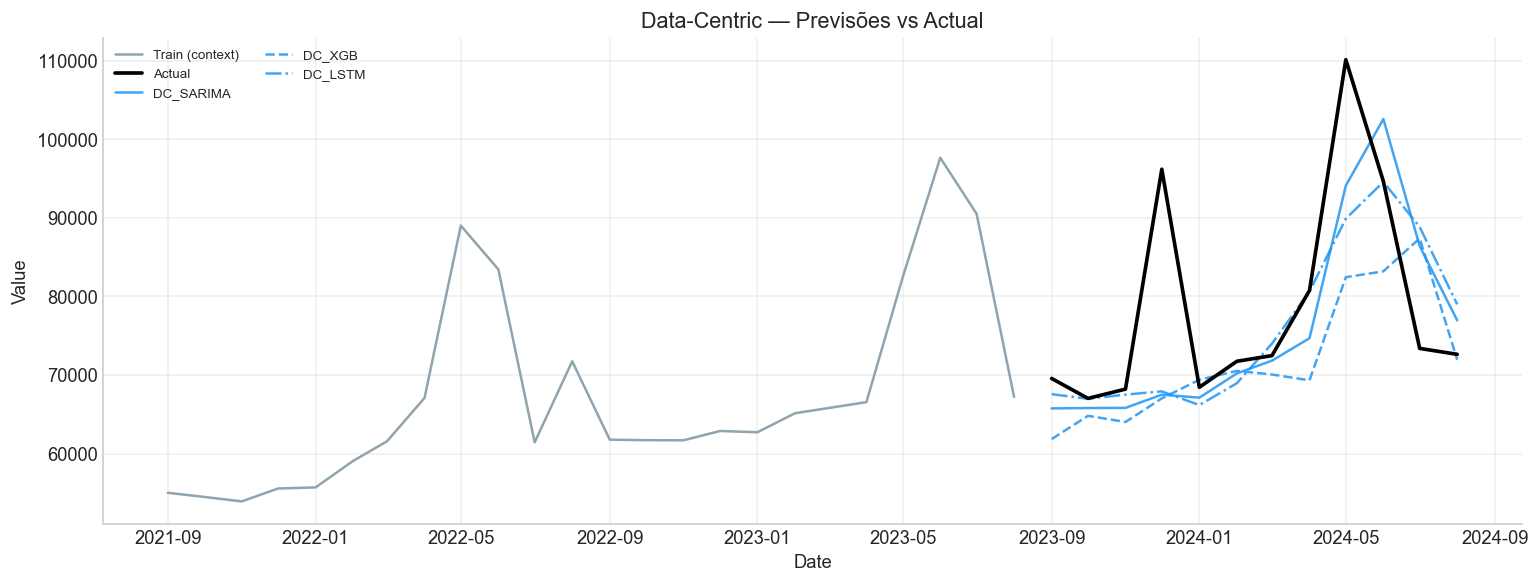

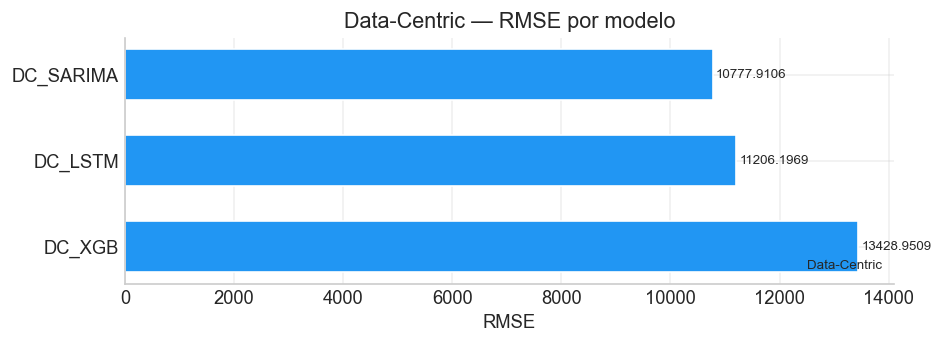

In [64]:
# ── Execução: Pipeline Data-Centric completo ──────────────────────────────────
#
# Pré-requisito: rodar Seções 1 (utilitários) e 2 (carregamento) antes desta célula
# Variáveis esperadas: train, test, DC_WINDOW, SEASONAL_PERIOD, TEST_HORIZON,
#                      SEED, OUTPUT_PATH, EXP_NAME

# ── 1. Preparação ─────────────────────────────────────────────────────────────
print("=" * 60)
print("PIPELINE DATA-CENTRIC")
print("=" * 60)

dc = prepare_dc_pipeline(train, window=DC_WINDOW)

print(f"Box-Cox λ={dc['bc_params']['lambda']:.4f}  shift={dc['bc_params']['shift']:.2e}")
print(f"Matriz X : {dc['X_dc_sc'].shape}  "
      f"seq={len(dc['seq_cols'])} cols  stat={len(dc['stat_cols'])} cols")
print(f"seq_cols : {dc['seq_cols'][:3]} … [{len(dc['seq_cols'])} total]")
print(f"stat_cols: {dc['stat_cols']}")

# Verificar primeiro ponto de teste esperado
expected_t1 = train.index[-1] + pd.DateOffset(months=1)
assert expected_t1 == test.index[0], (
    f"Split inconsistente: esperado {expected_t1.date()}, "
    f"obtido {test.index[0].date()}"
)
print(f"✓ Alinhamento temporal confirmado: primeiro ponto de teste = {test.index[0].date()}")

# ── 2. SARIMA ─────────────────────────────────────────────────────────────────
print("\n→ [SARIMA] treinando SARIMA(1,1,1)(1,1,1,12) no espaço Box-Cox …")
sarima_model, sarima_params = train_sarima_dc(dc["train_bc"])
preds_sarima = forecast_sarima_dc(sarima_model, TEST_HORIZON, dc["bc_params"])
print(f"  AIC={sarima_params['aic']:.2f}  BIC={sarima_params['bic']:.2f}  "
      f"obs={sarima_params['n_obs']}")

# ── 3. XGBoost ────────────────────────────────────────────────────────────────
print("\n→ [XGBoost] treinando sobre features DC escaladas …")
xgb_model, xgb_params = train_xgboost_dc(dc["X_dc_sc"], dc["y_dc_sc"], seed=SEED)
preds_xgb = recursive_forecast_rich(
    model        = xgb_model,
    history_bc   = dc["train_bc"],
    horizon      = TEST_HORIZON,
    window       = DC_WINDOW,
    feature_cols = dc["feature_cols"],
    n_train      = dc["n_train"],
    scaler_X     = dc["scaler_X"],
    scaler_y     = dc["scaler_y"],
    bc_params    = dc["bc_params"],
    model_type   = "xgboost",
)
print(f"  {xgb_params['n_estimators']} estimators  "
      f"lr={xgb_params['learning_rate']}  depth={xgb_params['max_depth']}")

# ── 4. LSTM dual-input ────────────────────────────────────────────────────────
print("\n→ [LSTM] treinando dual-input (seq + stat) …")
lstm_model, lstm_keras_hist, lstm_params = train_lstm_dual_dc(
    X_dc_sc       = dc["X_dc_sc"],
    y_dc_sc       = dc["y_dc_sc"],
    feature_cols  = dc["feature_cols"],
    seq_cols      = dc["seq_cols"],
    stat_cols     = dc["stat_cols"],
    seasonal_period = SEASONAL_PERIOD,
    seed          = SEED,
)
preds_lstm = recursive_forecast_rich(
    model        = lstm_model,
    history_bc   = dc["train_bc"],
    horizon      = TEST_HORIZON,
    window       = DC_WINDOW,
    feature_cols = dc["feature_cols"],
    n_train      = dc["n_train"],
    scaler_X     = dc["scaler_X"],
    scaler_y     = dc["scaler_y"],
    bc_params    = dc["bc_params"],
    model_type   = "lstm_dual",
    seq_cols     = dc["seq_cols"],
    stat_cols    = dc["stat_cols"],
)
print(f"  épocas: {lstm_params['epochs_run']}  "
      f"best_epoch={lstm_params['best_epoch']}  "
      f"val_loss={lstm_params['final_val_loss']:.6f}")

# ── 5. Métricas, alinhamento e artefatos ──────────────────────────────────────
print("\n── Resultados holdout (" + str(TEST_HORIZON) + " meses) ────────────────────────")

_pipeline_results = {
    "DC_SARIMA": (preds_sarima, sarima_params),
    "DC_XGB"   : (preds_xgb,   xgb_params),
    "DC_LSTM"  : (preds_lstm,  lstm_params),
}
dc_metrics_list = []

for label, (preds, params) in _pipeline_results.items():
    check_forecast_alignment(preds, test, label=label)      # AssertionError se desalinhado
    m = compute_metrics(test.values, preds, train.values, label=label)
    dc_metrics_list.append(m)

# Tabela de resultados
metrics_df_dc = pd.DataFrame(dc_metrics_list).set_index("model")
print()
display(metrics_df_dc)

# Armazenar previsões para Seção 7 (comparação entre abordagens)
dc_preds = {
    "DC_SARIMA": preds_sarima,
    "DC_XGB"   : preds_xgb,
    "DC_LSTM"  : preds_lstm,
}

# ── Visualização Data-Centric ─────────────────────────────────────────────────
fig = viz.plot_forecast_comparison(
    test, dc_preds, train=train, n_train_context=24,
    title="Data-Centric — Previsões vs Actual",
    fname="03_dc_forecasts.png",
)
plt.show()

fig = viz.plot_metric_bar(
    metrics_df_dc, metric="RMSE",
    title="Data-Centric — RMSE por modelo",
    fname="03b_dc_bar_rmse.png",
)
plt.show()


In [65]:
# TODO: transformações, limpeza, augmentation e feature engineering sobre os dados

---
## 5. Abordagem Model-Centric

Nesta parte, a estrutura do sinal é mantida mais próxima da série original e o
esforço principal fica concentrado no poder de adaptação e tuning dos modelos.


### 5.1 Feature Engineering — Lags Puros

**Filosofia Model-Centric:** mínima intervenção no sinal, máxima adaptação do modelo.

| Grupo | Feature | Construção | Causalidade |
|---|---|---|---|
| Lags | `lag_1 … lag_W` | `s.shift(k)`, k ≥ 1 | ✔ estrito |

Sem calendário, médias móveis ou diferenças sazonais. O modelo aprende padrões
diretamente das observações passadas.

**Escalonamento unificado:** `RobustScaler` fittado na série Box-Cox de treino.
Os lags são construídos *após* o escalonamento — input e output do modelo
compartilham a mesma escala, permitindo a recursão simples sem conversão de espaço.

In [66]:
# ── Feature Engineering e Preparação Model-Centric ──────────────────────────


def make_lag_features(series_sc, window=12):
    """
    Constrói matriz de lags puros a partir de uma série já escalonada.

    Parâmetros
    ----------
    series_sc : pd.Series — série na escala de treino (RobustScaler).
    window    : int       — número de lags (lag_1 … lag_window).

    Retorna
    -------
    X           : pd.DataFrame shape (n - window, window)
    y           : pd.Series   shape (n - window,)
    feature_cols: list[str]   — ['lag_1', ..., 'lag_window']

    Garantia anti-leakage
    ---------------------
    lag_k = series_sc.shift(k) — toda feature referencia t-k (k >= 1).
    dropna() remove as primeiras `window` linhas sem dados suficientes.
    """
    df = pd.DataFrame({'y': series_sc})
    for k in range(1, window + 1):
        df[f'lag_{k}'] = series_sc.shift(k)
    df = df.dropna()

    feature_cols = [f'lag_{k}' for k in range(1, window + 1)]
    X = df[feature_cols]
    y = df['y']
    return X, y, feature_cols


def prepare_mc_pipeline(train, window=12):
    """
    Prepara todos os artefatos do pipeline Model-Centric.

    Etapas
    ------
    1. RobustScaler fittado na série original de treino → train_sc
    2. make_lag_features(train_sc) → (X_mc_sc, y_mc_sc, feature_cols)

    Sem Box-Cox: o MC opera diretamente na escala original (apenas
    RobustScaler para estabilizar a otimização numérica).

    Retorna
    -------
    dict com: train_sc, scaler, X_mc_sc, y_mc_sc, feature_cols, n_train

    Garantia anti-leakage
    ---------------------
    RobustScaler estimado SOMENTE em `train`.
    """
    # 1. RobustScaler fittado na série original de treino
    scaler = RobustScaler()
    train_sc_vals = scaler.fit_transform(train.values.reshape(-1, 1)).ravel()
    train_sc = pd.Series(train_sc_vals, index=train.index, name=train.name)

    # 2. Lags construídos na escala RobustScaler
    X_mc_sc, y_mc_sc, feature_cols = make_lag_features(train_sc, window=window)

    return {
        'train_sc':     train_sc,
        'scaler':       scaler,
        'X_mc_sc':      X_mc_sc,
        'y_mc_sc':      y_mc_sc,
        'feature_cols': feature_cols,
        'n_train':      len(train),
    }


print('make_lag_features e prepare_mc_pipeline carregados.')

make_lag_features e prepare_mc_pipeline carregados.


### 5.2 SARIMA com Busca de Hiperparâmetros

Grid search sobre ordens `(p, d, q) x (P, D, Q, 12)` usando **AIC** como critério.

- `d = D = 1` fixos (diferenciação padrão para séries mensais)
- `p, q ∈ {0, 1, 2}` ; `P, Q ∈ {0, 1}`
- Convergência tolerante: combos que falham são silenciados e pulados
- Aviso explícito se nenhuma combinação convergir

In [67]:
# ── SARIMA Model-Centric: busca de hiperparametros ──────────────────────────


def search_sarima_mc(train, d=1, D=1, s=12, max_p=2, max_q=2, max_P=1, max_Q=1):
    """
    Grid search de hiperparametros SARIMA via AIC.

    Parâmetros
    ----------
    train       : pd.Series — série original de treino.
    d, D        : int       — ordens de diferenciacao (fixas).
    s           : int       — periodo sazonal (12 para dados mensais).
    max_p/q/P/Q : int       — limites superiores do grid.

    Retorna
    -------
    fitted_model : SARIMAXResultsWrapper — melhor modelo fittado.
    best_order   : dict — {'order': (p,d,q), 'seasonal_order': (P,D,Q,s), 'aic': float}

    Tolerância a falhas
    -------------------
    Combinacoes que levantam qualquer excecao (convergencia, inversao)
    sao silenciadas e puladas. Se nenhuma convergir, levanta RuntimeError.
    """
    best_aic   = float('inf')
    best_model = None
    best_order = None
    n_failed   = 0

    grid = list(itertools.product(
        range(max_p + 1), range(max_q + 1),
        range(max_P + 1), range(max_Q + 1),
    ))

    for p, q, P, Q in grid:
        order          = (p, d, q)
        seasonal_order = (P, D, Q, s)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                res = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=200, method='lbfgs')
            if res.aic < best_aic:
                best_aic   = res.aic
                best_model = res
                best_order = {
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': round(best_aic, 4),
                }
        except Exception:
            n_failed += 1

    if best_model is None:
        raise RuntimeError(
            f'[SARIMA-MC] Nenhuma das {len(grid)} combinacoes convergiu.'
        )

    print(
        f'[SARIMA-MC] Grid: {len(grid)} combos | falhas: {n_failed} | '
        f"melhor: {best_order['order']} x {best_order['seasonal_order']} "
        f"AIC={best_order['aic']}"
    )
    return best_model, best_order


def forecast_sarima_mc(fitted_model, horizon):
    """
    Gera previsoes SARIMA na escala original da série.

    Parametros
    ----------
    fitted_model : SARIMAXResultsWrapper
    horizon      : int  — passos a frente

    Retorna
    -------
    np.ndarray shape (horizon,) na escala original da série.
    """
    fc = fitted_model.forecast(steps=horizon)
    return fc.values


print('search_sarima_mc e forecast_sarima_mc carregados.')

search_sarima_mc e forecast_sarima_mc carregados.


### 5.3 XGBoost com Optuna

Busca bayesiana (TPE) de hiperparâmetros via **Optuna**.

- Validação temporal: últimos `SEASONAL_PERIOD` meses do treino como hold-out interno
- Score do trial: RMSE na partição de validação (escala RobustScaler)
- Modelo final retreinado em todos os dados de treino com os melhores parâmetros

In [68]:
# ── XGBoost Model-Centric com Optuna ─────────────────────────────────────────

optuna.logging.set_verbosity(optuna.logging.WARNING)


def _validate_mc_trial_forecast(preds_sc, y_ref, model_name='MC'):
    """
    Rejeita trials com previsoes nao finitas ou numericamente absurdas.

    A verificacao e feita na escala do pipeline MC (apos RobustScaler),
    comparando a magnitude das previsoes com a escala observada no alvo de
    referencia do proprio split temporal.
    """
    preds_arr = np.asarray(preds_sc, dtype=float).ravel()
    ref_arr   = np.asarray(y_ref, dtype=float).ravel()

    if preds_arr.size != ref_arr.size:
        raise optuna.exceptions.TrialPruned(
            f'{model_name}: horizonte previsto inconsistente ({preds_arr.size} != {ref_arr.size})'
        )

    if not np.all(np.isfinite(preds_arr)):
        raise optuna.exceptions.TrialPruned(
            f'{model_name}: previsoes nao finitas geradas no trial'
        )

    ref_scale = float(np.nanmax(np.abs(ref_arr))) if ref_arr.size else 1.0
    ref_scale = max(ref_scale, 1.0)
    absurd_limit = max(1e3, 50.0 * ref_scale)

    max_abs_pred = float(np.max(np.abs(preds_arr))) if preds_arr.size else 0.0
    if max_abs_pred > absurd_limit:
        raise optuna.exceptions.TrialPruned(
            f'{model_name}: previsao absurda detectada (max_abs_pred={max_abs_pred:.3e}, limit={absurd_limit:.3e})'
        )

    rmse = float(np.sqrt(np.mean((ref_arr - preds_arr) ** 2)))
    if (not np.isfinite(rmse)) or rmse > absurd_limit:
        raise optuna.exceptions.TrialPruned(
            f'{model_name}: RMSE absurdo detectado no trial (rmse={rmse:.3e}, limit={absurd_limit:.3e})'
        )

    return rmse


def _xgb_mc_objective(trial, X_mc_sc, y_mc_sc, seasonal_period=12):
    """
    Funcao objetivo Optuna para XGBoost MC.

    Score: RMSE de forecast recursivo multi-step sobre os ultimos
    `seasonal_period` pontos — mesma logica de inferencia usada em producao.

    Split temporal:
        X_fit / y_fit    → treino do modelo
        last_window_val  → janela de entrada para o forecast recursivo
                           (ultimos window_size valores antes do periodo de avaliacao)
        y_eval           → ground truth na escala RobustScaler

    Anti-leakage
    ------------
    last_window_val e construida a partir de y_mc_sc[:-n_val], que nunca
    inclui os alvos do periodo de avaliacao.
    """
    window_size = X_mc_sc.shape[1]
    n_val       = seasonal_period

    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state':     SEED,
        'n_jobs':           -1,
        'verbosity':        0,
    }

    # Prefixo temporal de treino
    X_fit = X_mc_sc.iloc[:-n_val]
    y_fit = y_mc_sc.iloc[:-n_val]

    model = XGBRegressor(**params)
    model.fit(X_fit, y_fit)

    # Janela de entrada: ultimos window_size valores antes do periodo de avaliacao.
    # y_mc_sc[i] = train_sc[i + window], portanto:
    #   y_mc_sc[-n_val - window_size : -n_val] == train_sc[n - n_val - window_size : n - n_val]
    last_window_val = y_mc_sc.values[-n_val - window_size : -n_val]

    # Forecast recursivo multi-step (identico a inferencia em producao)
    preds_sc = recursive_forecast_simple(
        model=model, last_window=last_window_val,
        horizon=n_val, model_type='xgboost',
    )

    y_eval = y_mc_sc.values[-n_val:]
    return _validate_mc_trial_forecast(preds_sc, y_eval, model_name='XGBoost-MC')


def train_xgboost_mc(X_mc_sc, y_mc_sc, n_trials=50, seasonal_period=12, seed=42):
    """
    Treina XGBoost MC com busca Optuna (TPE) e retreina na base completa.

    Retorna
    -------
    model       : XGBRegressor treinado com melhores params em todo treino.
    best_params : dict — hiperparametros vencedores.
    """
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(
        lambda trial: _xgb_mc_objective(trial, X_mc_sc, y_mc_sc, seasonal_period),
        n_trials=n_trials,
        show_progress_bar=False,
    )

    best_params = study.best_params
    print(
        f'[XGBoost-MC] Trials: {n_trials} | '
        f'Melhor RMSE (recursivo multi-step): {study.best_value:.4f}'
    )
    print(f'[XGBoost-MC] Best params: {best_params}')

    # Retreino completo
    final_params = {**best_params, 'random_state': seed, 'n_jobs': -1, 'verbosity': 0}
    model = XGBRegressor(**final_params)
    model.fit(X_mc_sc, y_mc_sc)
    return model, best_params


print('train_xgboost_mc carregado.')

train_xgboost_mc carregado.


### 5.4 LSTM Simples com Optuna — Split Temporal Explícito 3-Vias

Para evitar que o sinal de early stopping contamine o score do trial,
o conjunto de treino interno é dividido em **três blocos estritamente temporais**:

```
|<──── train_inner ────>|<── val_inner ──>|<── eval_outer ──>|
                         early stopping     score do trial
```

- **train_inner**: ajuste dos pesos da rede
- **val_inner**: sinal de `EarlyStopping` (paciência = 15 épocas) — nunca pontuado
- **eval_outer**: único bloco que determina o score do trial

Cada bloco tem `SEASONAL_PERIOD` meses. `train_inner` recebe o restante.
Retreino final usa `train[:-seasonal_period]` com `EarlyStopping` no último bloco.

In [69]:
# ── LSTM Simples Model-Centric com Optuna ────────────────────────────────────


def build_lstm_simple_mc(window_size, lstm_units=64, dropout=0.2, learning_rate=1e-3):
    """
    LSTM simples: lags puros como timesteps → Input shape (window_size, 1).

    Arquitetura
    -----------
    Input(window_size, 1) → LSTM(lstm_units) → Dropout → Dense(1)

    Compativel com model_type='lstm' em recursive_forecast_simple:
        x.reshape(1, window_size, 1)
    """
    inp = keras.Input(shape=(window_size, 1), name='lags_input')
    x   = KL.LSTM(lstm_units, name='lstm_layer')(inp)
    x   = KL.Dropout(dropout, name='dropout')(x)
    out = KL.Dense(1, name='output')(x)
    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
    )
    return model


def _lstm_mc_objective(trial, X_mc_sc, y_mc_sc, seasonal_period=12, seed=42):
    """
    Funcao objetivo Optuna para LSTM simples MC — split 3-vias.

    Blocos temporais:
        train_inner → pesos da rede
        val_inner   → EarlyStopping (patience=15) — NAO pontua o trial
        eval_outer  → score do trial: RMSE de forecast recursivo multi-step

    Score alinhado com inferencia
    -----------------------------
    eval_outer e pontuado por forecast recursivo a partir da ultima janela
    de (train_inner + val_inner), nao por predict() com lags verdadeiros.
    Isso alinha o criterio de busca com a logica de recursive_forecast_simple
    usada em producao.
    """
    n       = len(X_mc_sc)
    n_eval  = seasonal_period
    n_val   = seasonal_period
    n_inner = n - n_val - n_eval

    if n_inner < seasonal_period:
        raise optuna.exceptions.TrialPruned()

    X_arr       = X_mc_sc.values
    y_arr       = y_mc_sc.values
    window_size = X_arr.shape[1]

    X_inner = X_arr[:n_inner]
    y_inner = y_arr[:n_inner]
    X_val   = X_arr[n_inner : n_inner + n_val]
    y_val   = y_arr[n_inner : n_inner + n_val]
    y_eval  = y_arr[n_inner + n_val:]        # ground truth para pontuar

    lstm_units = trial.suggest_int('lstm_units', 16, 128, step=16)
    dropout    = trial.suggest_float('dropout', 0.0, 0.5, step=0.1)
    lr         = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])

    tf.random.set_seed(seed)
    np.random.seed(seed)

    model = build_lstm_simple_mc(
        window_size=window_size, lstm_units=lstm_units,
        dropout=dropout, learning_rate=lr,
    )

    # val_inner: usado exclusivamente para EarlyStopping — NAO pontua o trial
    cb = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True
    )
    model.fit(
        X_inner[:, :, np.newaxis], y_inner,
        validation_data=(X_val[:, :, np.newaxis], y_val),
        epochs=200, batch_size=batch_size,
        callbacks=[cb], verbose=0, shuffle=False,
    )

    # Forecast recursivo multi-step sobre eval_outer
    # Janela de entrada: ultimos window_size valores de (train_inner + val_inner)
    # y_arr[i] = train_sc[i + window], logo:
    #   y_arr[n_inner + n_val - window_size : n_inner + n_val]
    #   == train_sc[n_inner + n_val : n_inner + n_val + window_size]   NÃO
    #   == train_sc[n_inner + n_val + window - window_size : n_inner + n_val + window]
    #   = ultimos window_size valores da serie scaled antes do periodo eval_outer
    last_window_eval = y_arr[n_inner + n_val - window_size : n_inner + n_val]

    preds_sc = recursive_forecast_simple(
        model=model, last_window=last_window_eval,
        horizon=n_eval, model_type='lstm',
    )
    return _validate_mc_trial_forecast(preds_sc, y_eval, model_name='LSTM-MC')


def train_lstm_simple_mc(
    X_mc_sc, y_mc_sc, n_trials=30, seasonal_period=12,
    max_epochs=300, patience=25, seed=42,
):
    """
    Treina LSTM simples MC com Optuna (split 3-vias) e retreina o melhor modelo.

    Busca
    -----
    - n_trials com split train_inner | val_inner | eval_outer
    - Score: RMSE em eval_outer

    Retreino final
    --------------
    - Dados de treino: X_mc_sc[:-seasonal_period]
    - EarlyStopping em: X_mc_sc[-seasonal_period:]

    Retorna
    -------
    model       : keras.Model treinado.
    best_params : dict — hiperparametros vencedores.
    """
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(
        lambda trial: _lstm_mc_objective(
            trial, X_mc_sc, y_mc_sc, seasonal_period, seed
        ),
        n_trials=n_trials,
        show_progress_bar=False,
    )

    best_params = study.best_params
    print(
        f'[LSTM-MC] Trials: {n_trials} | '
        f'Melhor RMSE (eval_outer): {study.best_value:.4f}'
    )
    print(f'[LSTM-MC] Best params: {best_params}')

    # ── Retreino final ─────────────────────────────────────────────────────
    tf.random.set_seed(seed)
    np.random.seed(seed)

    n_val_f = seasonal_period
    X_fit   = X_mc_sc.values[: -n_val_f]
    y_fit   = y_mc_sc.values[: -n_val_f]
    X_valf  = X_mc_sc.values[-n_val_f :]
    y_valf  = y_mc_sc.values[-n_val_f :]

    window_size = X_mc_sc.shape[1]
    final_model = build_lstm_simple_mc(
        window_size=window_size,
        lstm_units=best_params['lstm_units'],
        dropout=best_params['dropout'],
        learning_rate=best_params['learning_rate'],
    )

    cb = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=patience, restore_best_weights=True
    )
    final_model.fit(
        X_fit[:, :, np.newaxis], y_fit,
        validation_data=(X_valf[:, :, np.newaxis], y_valf),
        epochs=max_epochs,
        batch_size=best_params['batch_size'],
        callbacks=[cb], verbose=0, shuffle=False,
    )

    return final_model, best_params


print('build_lstm_simple_mc, _lstm_mc_objective e train_lstm_simple_mc carregados.')

build_lstm_simple_mc, _lstm_mc_objective e train_lstm_simple_mc carregados.


In [70]:
# ── Patch: funcoes Model-Centric ──────────────────────────────────────────────
#
# Os objetivos Optuna (_xgb_mc_objective, _lstm_mc_objective) sao referenciados
# via lookup global dentro dos lambdas de study.optimize. O patch aqui, aplicado
# antes de chamar train_xgboost_mc / train_lstm_simple_mc, faz os lambdas usarem
# automaticamente as versoes instrumentadas — sem tocar na logica interna.
# ─────────────────────────────────────────────────────────────────────────────
if not globals().get("_cost_timing_patched_mc", False):
    prepare_mc_pipeline  = timed("MC.features")(prepare_mc_pipeline)
    search_sarima_mc     = timed("MC.SARIMA.tune")(search_sarima_mc)   # grid-search = tune+fit
    forecast_sarima_mc   = timed("MC.SARIMA.forecast")(forecast_sarima_mc)

    # Objetivos Optuna: acumular tempo de cada trial individualmente.
    # Como _xgb_mc_objective e _lstm_mc_objective sao resolvidos via lookup
    # global no momento da chamada (dentro do lambda de study.optimize),
    # basta redefinir os nomes aqui — as funcoes train_*_mc ja serao
    # chamadas com os nomes patchados sem qualquer mudanca interna.
    _xgb_mc_objective    = timed_acc("MC.XGB.tuning")(_xgb_mc_objective)
    _lstm_mc_objective   = timed_acc("MC.LSTM.tuning")(_lstm_mc_objective)

    train_xgboost_mc     = timed("MC.XGB.total_train")(train_xgboost_mc)
    train_lstm_simple_mc = timed("MC.LSTM.total_train")(train_lstm_simple_mc)

    # recursive_forecast_simple e chamado 2x na celula MC (XGB, depois LSTM).
    _orig_rf_simple = recursive_forecast_simple
    _rf_simple_labels = ["MC.XGB.forecast", "MC.LSTM.forecast"]
    _rf_simple_idx = [0]

    def recursive_forecast_simple(*args, **kwargs):
        idx = _rf_simple_idx[0]
        lbl = _rf_simple_labels[idx] if idx < len(_rf_simple_labels) else f"MC.model{idx}.forecast"
        t0 = time.perf_counter()
        result = _orig_rf_simple(*args, **kwargs)
        _timing_registry[lbl] = time.perf_counter() - t0
        _rf_simple_idx[0] += 1
        return result

    _cost_timing_patched_mc = True

# Reset contadores para medicoes limpas
_rf_simple_idx[0] = 0

print("Timing patches MC aplicados.")
print("  prepare_mc_pipeline | search_sarima_mc | forecast_sarima_mc")
print("  train_xgboost_mc    | train_lstm_simple_mc | recursive_forecast_simple (x2)")
print("  Objetivos Optuna: _xgb_mc_objective | _lstm_mc_objective (acumulados)")


Timing patches MC aplicados.
  prepare_mc_pipeline | search_sarima_mc | forecast_sarima_mc
  train_xgboost_mc    | train_lstm_simple_mc | recursive_forecast_simple (x2)
  Objetivos Optuna: _xgb_mc_objective | _lstm_mc_objective (acumulados)


In [71]:
# ── Execução: Pipeline Model-Centric completo ────────────────────────────────
#
# Pre-requisito: rodar Secao 2 (carregamento) antes de executar esta celula.
#
# Fluxo:
#   1. prepare_mc_pipeline → série original + RobustScaler + lags puros
#   2. SARIMA  → grid search (AIC) na série original → forecast
#   3. XGBoost → Optuna (RMSE val)  → recursive_forecast_simple → inverse scaler
#   4. LSTM    → Optuna (3-way)     → recursive_forecast_simple → inverse scaler
#   5. compute_metrics
# ──────────────────────────────────────────────────────────────────────────────
set_global_seed(SEED)

mc_window = SEASONAL_PERIOD   # 12 lags puros

# ── 1. Preparacao ─────────────────────────────────────────────────────────────
print('=== Preparacao MC ===')
mc_art       = prepare_mc_pipeline(train, window=mc_window)
train_sc     = mc_art['train_sc']
scaler       = mc_art['scaler']
X_mc_sc      = mc_art['X_mc_sc']
y_mc_sc      = mc_art['y_mc_sc']
feature_cols = mc_art['feature_cols']
n_train      = mc_art['n_train']

# Janela de entrada para recursão (escala RobustScaler)
last_window_sc = train_sc.values[-mc_window:]

print(
    f'Amostras de treino: {len(train_sc)} | '
    f'Amostras com lags: {len(X_mc_sc)} | '
    f'Features: {X_mc_sc.shape[1]}'
)

# ── 2. SARIMA – grid search na série original ─────────────────────────────────
print('\n=== SARIMA Model-Centric ===')
sarima_mc_model, sarima_mc_order = search_sarima_mc(train)
sarima_mc_preds = forecast_sarima_mc(sarima_mc_model, TEST_HORIZON)
check_forecast_alignment(sarima_mc_preds, test, label='SARIMA-MC')
sarima_mc_metrics = compute_metrics(
    test.values, sarima_mc_preds, train.values, label='SARIMA-MC'
)

# ── 3. XGBoost – Optuna ───────────────────────────────────────────────────────
print('\n=== XGBoost Model-Centric ===')
xgb_mc_model, xgb_mc_best = train_xgboost_mc(
    X_mc_sc, y_mc_sc, n_trials=50, seasonal_period=SEASONAL_PERIOD, seed=SEED
)

# Recursão em escala RobustScaler → inverse scaler → escala original
xgb_mc_preds_sc = recursive_forecast_simple(
    model=xgb_mc_model, last_window=last_window_sc,
    horizon=TEST_HORIZON, model_type='xgboost',
)
xgb_mc_preds = scaler.inverse_transform(xgb_mc_preds_sc.reshape(-1, 1)).ravel()
check_forecast_alignment(xgb_mc_preds, test, label='XGBoost-MC')
xgb_mc_metrics = compute_metrics(
    test.values, xgb_mc_preds, train.values, label='XGBoost-MC'
)

# ── 4. LSTM Simples – Optuna 3-way ───────────────────────────────────────────
print('\n=== LSTM Simples Model-Centric ===')
lstm_mc_model, lstm_mc_best = train_lstm_simple_mc(
    X_mc_sc, y_mc_sc,
    n_trials=30, seasonal_period=SEASONAL_PERIOD,
    max_epochs=300, patience=25, seed=SEED,
)

lstm_mc_preds_sc = recursive_forecast_simple(
    model=lstm_mc_model, last_window=last_window_sc,
    horizon=TEST_HORIZON, model_type='lstm',
)
lstm_mc_preds = scaler.inverse_transform(lstm_mc_preds_sc.reshape(-1, 1)).ravel()
check_forecast_alignment(lstm_mc_preds, test, label='LSTM-MC')
lstm_mc_metrics = compute_metrics(
    test.values, lstm_mc_preds, train.values, label='LSTM-MC'
)

# ── 5. Consolidar metricas ────────────────────────────────────────────────────
mc_preds = {
    'SARIMA-MC':  sarima_mc_preds,
    'XGBoost-MC': xgb_mc_preds,
    'LSTM-MC':    lstm_mc_preds,
}
metrics_df_mc = pd.DataFrame(
    [sarima_mc_metrics, xgb_mc_metrics, lstm_mc_metrics]
).set_index('model')

print('\n=== Metricas Model-Centric ===')
print(metrics_df_mc.to_string())

# ── 6. Visualização Model-Centric ────────────────────────────────────────────
fig = viz.plot_forecast_comparison(
    test, mc_preds, train=train, n_train_context=24,
    title="Model-Centric — Previsões vs Actual",
    fname="04_mc_forecasts.png",
)
plt.show()

fig = viz.plot_metric_bar(
    metrics_df_mc, metric="RMSE",
    title="Model-Centric — RMSE por modelo",
    fname="04b_mc_bar_rmse.png",
)
plt.show()


=== Preparacao MC ===
Amostras de treino: 241 | Amostras com lags: 229 | Features: 12

=== SARIMA Model-Centric ===
[SARIMA-MC] Grid: 36 combos | falhas: 0 | melhor: (1, 1, 2) x (1, 1, 1, 12) AIC=4210.7282

=== XGBoost Model-Centric ===
[XGBoost-MC] Trials: 50 | Melhor RMSE (recursivo multi-step): 0.2931
[XGBoost-MC] Best params: {'n_estimators': 900, 'learning_rate': 0.14879005064530765, 'max_depth': 5, 'subsample': 0.9540696128401708, 'colsample_bytree': 0.7133456145286303, 'min_child_weight': 9}

=== LSTM Simples Model-Centric ===


[W 2026-04-12 19:48:59,694] Trial 10 failed with parameters: {'lstm_units': 128, 'dropout': 0.30000000000000004, 'learning_rate': 0.00054633314034852, 'batch_size': 32} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\lucas\AppData\Local\Programs\Python\Python313\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\lucas\AppData\Local\Temp\ipykernel_26936\2455163562.py", line 126, in <lambda>
    lambda trial: _lstm_mc_objective(
                  ~~~~~~~~~~~~~~~~~~^
        trial, X_mc_sc, y_mc_sc, seasonal_period, seed
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ),
    ^
  File "C:\Users\lucas\AppData\Local\Temp\ipykernel_26936\2455163562.py", line 78, in _lstm_mc_objective
    model.fit(
    ~~~~~~~~~^
        X_inner[:, :, np.newaxis], y_inner,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        callbacks=[cb], verbose=0, shu

KeyboardInterrupt: 

---
## 6. Baselines Modernos

Bloco de comparação com modelos de referência modernos executados no mesmo
recorte temporal do holdout principal, para manter a comparação justa.


### Modelos baseline

| Modelo | Tipo | Configuração | Tuning |
|---|---|---|---|
| **Prophet** | Decomposição aditiva/multiplicativa | Sazonalidade anual auto, sazonal_mode detectado | Nenhum |
| **Theta** | Decomposição em theta-lines | AutoTheta (statsforecast) ou ThetaModel (statsmodels) | Nenhum |
| **ETS** | Suavização exponencial | Seleção automática por AIC (grid mínimo) | Nenhum |

**Critério de comparação justa:** todos os baselines treinam no mesmo `train` holdout,
prevêem o mesmo `TEST_HORIZON` e calculam métricas na mesma escala original.
Nenhum parâmetro é derivado de `test`.

**Interface padronizada:** cada função retorna `(preds: np.ndarray, params: dict)`
compatível com `compute_metrics` e `save_dc_artifacts`.

In [ ]:
# == 6.1 Baseline: Prophet ====================================================
#
# Configuração padrão para série univariada mensal:
#   - yearly_seasonality = True       (fourier automático)
#   - weekly/daily seasonality = False (irrelevante para dados mensais)
#   - seasonality_mode: 'multiplicative' se min(train) > 0, 'additive' otherwise
#
# O que é default vs. configuração mínima necessária:
#   DEFAULT  : yearly_seasonality=True, changepoint_prior_scale=0.05
#   MINIMO   : freq mensal, modo sazonal compatível com os dados
#   NAO FEITO: tuning de changepoint_prior_scale, holidays, regressores
# =============================================================================

def train_predict_prophet(
    train,
    horizon,
    seed=42,
):
    """
    Treina Prophet com configuração padrão para série mensal univariada.

    Parâmetros
    ----------
    train   : pd.Series (DatetimeIndex mensal) — treino na escala original
    horizon : int — passos à frente
    seed    : int — seed para o sampler Stan (reprodutibilidade)

    Retorna
    -------
    preds  : np.ndarray shape (horizon,) na escala original
    params : dict com configuração efetiva

    Levanta
    -------
    ImportError se o pacote prophet não estiver instalado.
    """
    try:
        import prophet as _prophet_pkg
        from prophet import Prophet
        import logging
        logging.getLogger("prophet").setLevel(logging.WARNING)
        logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
    except ImportError:
        raise ImportError(
            "[Prophet] Pacote nao instalado. Execute: pip install prophet"
        )

    y_arr = train.values.astype(float)
    if y_arr.min() <= 0:
        seasonality_mode = "additive"     # necessário para valores <= 0
    else:
        seasonality_mode = "multiplicative"  # melhor para séries positivas com sazon. proporcional

    df_train = pd.DataFrame({"ds": train.index, "y": y_arr})

    model = Prophet(
        yearly_seasonality = True,     # default Prophet
        weekly_seasonality = False,    # configuração mínima: irrelevante para dados mensais
        daily_seasonality  = False,    # configuração mínima: irrelevante para dados mensais
        seasonality_mode   = seasonality_mode,
        # changepoint_prior_scale: mantido no default do Prophet (0.05)
        # holidays: nenhum
    )

    import contextlib, io as _io
    with contextlib.redirect_stdout(_io.StringIO()):
        model.fit(df_train, seed=seed)

    # Gerar datas futuras detectando a frequência do índice
    freq = pd.infer_freq(train.index) or "MS"
    future_dates = pd.date_range(
        start   = train.index[-1] + pd.tseries.frequencies.to_offset(freq),
        periods = horizon,
        freq    = freq,
    )
    future   = pd.DataFrame({"ds": future_dates})
    forecast = model.predict(future)
    preds    = forecast["yhat"].values

    params = {
        "model"            : "Prophet",
        "yearly_seasonality": True,
        "seasonality_mode" : seasonality_mode,
        "changepoint_prior": 0.05,    # default Prophet — nao tunado
        "freq"             : freq,
        "n_train"          : len(train),
        "space"            : "original (Prophet nao usa Box-Cox)",
    }
    return np.asarray(preds, dtype=float), params


print("train_predict_prophet carregado.")


In [ ]:
# == 6.2 Baseline: Theta ======================================================
#
# Configuração padrão:
#   - AutoTheta (statsforecast): seleção automática do theta via cross-validation
#   - ThetaModel (statsmodels): Theta(2) com dessazonalização automática
#   - Manual Theta(2): SES + drift linear (fallback final)
#
# O que é default vs. configuração mínima necessária:
#   DEFAULT  : theta=2, dessazonalização se seasonal_period fornecido
#   MINIMO   : seasonal_period=12 para dados mensais
#   NAO FEITO: tuning do parâmetro theta
#
# Cadeia de fallback:
#   1. statsforecast.AutoTheta  (preferido — moderno, robusto)
#   2. statsmodels.ThetaModel   (fallback 1 — disponível desde statsmodels 0.12)
#   3. SES + drift manual       (fallback 2 — sem dependências externas)
# =============================================================================

def train_predict_theta(
    train,
    horizon,
    seasonal_period=12,
):
    """
    Modelo Theta para série mensal univariada.

    Parâmetros
    ----------
    train           : pd.Series — treino na escala original
    horizon         : int — passos à frente
    seasonal_period : int — período sazonal (12 para dados mensais)

    Retorna
    -------
    preds  : np.ndarray shape (horizon,) na escala original
    params : dict com backend usado e configuração efetiva
    """

    # Tentativa 1: statsforecast AutoTheta
    try:
        from statsforecast import StatsForecast as _SF
        from statsforecast.models import AutoTheta as _AutoTheta

        freq = pd.infer_freq(train.index) or "MS"
        df_sf = pd.DataFrame({
            "unique_id": "series",
            "ds"       : train.index,
            "y"        : train.values.astype(float),
        })
        sf = _SF(
            models  = [_AutoTheta(season_length=seasonal_period)],
            freq    = freq,
            n_jobs  = 1,
        )
        import contextlib, io as _io2
        with contextlib.redirect_stdout(_io2.StringIO()):
            sf.fit(df_sf)
        fc    = sf.predict(h=horizon)
        preds = fc["AutoTheta"].values

        return np.asarray(preds, dtype=float), {
            "model"         : "AutoTheta",
            "season_length" : seasonal_period,
            "backend"       : "statsforecast",
            "n_train"       : len(train),
            "space"         : "original",
        }

    except (ImportError, Exception) as _e1:
        print(
            f"  [Theta] statsforecast indisponivel ({type(_e1).__name__}: {_e1}). "
            "Tentando statsmodels ThetaModel..."
        )

    # Tentativa 2: statsmodels ThetaModel
    try:
        from statsmodels.tsa.forecasting.theta import ThetaModel as _ThetaModel

        tm    = _ThetaModel(train, period=seasonal_period, deseasonalize=True, use_test=False)
        res   = tm.fit()
        preds = np.asarray(res.forecast(horizon), dtype=float)

        return preds, {
            "model"         : "ThetaModel(theta=2)",
            "period"        : seasonal_period,
            "deseasonalize" : True,
            "backend"       : "statsmodels",
            "n_train"       : len(train),
            "space"         : "original",
        }

    except (ImportError, Exception) as _e2:
        print(
            f"  [Theta] statsmodels ThetaModel falhou ({type(_e2).__name__}: {_e2}). "
            "Usando Theta(2) manual (SES + drift)."
        )

    # Fallback final: Theta(2) manual — SES + drift linear
    # Equivalente ao Theta method original (Assimakopoulos & Nikolopoulos, 2000):
    #   Theta(0) = componente de tendência linear
    #   Theta(2) = 2*SES - Theta(0)
    #   Forecast = 0.5 * Theta(0) + 0.5 * Theta(2) = SES com drift
    from statsmodels.tsa.holtwinters import SimpleExpSmoothing as _SES

    y      = train.values.astype(float)
    n      = len(y)
    ses    = _SES(y, initialization_method="estimated").fit(optimized=True)
    ses_fc = ses.forecast(horizon)

    # Drift = media do slope linear na metade da serie (Theta(0) correction)
    slope     = (y[-1] - y[0]) / max(n - 1, 1)
    drift_fc  = y[-1] + slope * np.arange(1, horizon + 1)

    preds = 0.5 * ses_fc + 0.5 * drift_fc

    return np.asarray(preds, dtype=float), {
        "model"    : "Theta2_manual",
        "alpha_ses": round(float(ses.params["smoothing_level"]), 6),
        "slope"    : round(float(slope), 6),
        "backend"  : "manual_fallback",
        "n_train"  : len(train),
        "space"    : "original",
    }


print("train_predict_theta carregado.")


In [ ]:
# == 6.3 Baseline: ETS ========================================================
#
# Configuração padrão:
#   Seleção automática por AIC sobre um grid mínimo de componentes.
#   Grid: combinações de {A, M} x {N, Ad} x {A, M, N} para error/trend/seasonal.
#   Configs M-* excluídas automaticamente se min(train) <= 0.
#
# O que é default vs. configuração mínima necessária:
#   DEFAULT  : seleção por AIC é o comportamento esperado de ETS "out-of-the-box"
#              (equivalente a forecast::ets() do R)
#   MINIMO   : seasonal_periods=12 para dados mensais
#   NAO FEITO: seleção de inicialização, damping force, etc.
#
# Fallback: ExponentialSmoothing (Holt-Winters) se ETSModel nao disponivel.
# =============================================================================

def train_predict_ets(
    train,
    horizon,
    seasonal_period=12,
):
    """
    ETS com seleção automática de componentes por AIC.

    Tenta as combinações mais comuns de error/trend/seasonal e seleciona
    a que minimiza AIC. Comportamento equivalente a forecast::ets() do R.

    Parâmetros
    ----------
    train           : pd.Series — treino na escala original
    horizon         : int — passos à frente
    seasonal_period : int — período sazonal (12 para dados mensais)

    Retorna
    -------
    preds  : np.ndarray shape (horizon,) na escala original
    params : dict com configuração selecionada e AIC
    """
    from statsmodels.tsa.exponential_smoothing.ets import ETSModel as _ETSModel

    y_min   = float(train.min())
    allow_m = y_min > 0   # configs multiplicativas só funcionam com série positiva

    # Grid mínimo de configurações a avaliar (error, trend, damped, seasonal)
    # Inclui as combinações mais relevantes para série mensal com tendência e sazonalidade
    _grid = [
        ("add", "add",  True,  "add"),   # A,Ad,A  — damped Holt-Winters aditivo
        ("add", "add",  False, "add"),   # A,A,A   — Holt-Winters aditivo
        ("add", None,   False, "add"),   # A,N,A   — sem tendência, sazonal aditivo
    ]
    if allow_m:
        _grid += [
            ("mul", "mul", True,  "mul"),  # M,Md,M  — damped Holt-Winters multiplicativo
            ("mul", "mul", False, "mul"),  # M,M,M
            ("mul", None,  False, "mul"),  # M,N,M
        ]

    import warnings as _w_ets
    best_aic   = float("inf")
    best_model = None
    best_cfg   = None

    for error, trend, damped, seasonal in _grid:
        try:
            with _w_ets.catch_warnings():
                _w_ets.simplefilter("ignore")
                mod = _ETSModel(
                    train,
                    error            = error,
                    trend            = trend,
                    damped_trend     = damped if trend is not None else False,
                    seasonal         = seasonal,
                    seasonal_periods = seasonal_period,
                    initialization_method = "estimated",
                )
                res = mod.fit(disp=False, full_output=False)
            if res.aic < best_aic:
                best_aic   = res.aic
                best_model = res
                best_cfg   = (error, trend, damped, seasonal)
        except Exception:
            pass   # configuração invalida ou nao convergiu — pular

    if best_model is not None:
        preds  = np.asarray(best_model.forecast(horizon), dtype=float)
        e, t, d, s = best_cfg
        return preds, {
            "model"           : f"ETS({e[0].upper()},{(t[0].upper() if t else 'N') + ('d' if d and t else '')},{s[0].upper()})",
            "error"           : e,
            "trend"           : t,
            "damped"          : d,
            "seasonal"        : s,
            "seasonal_periods": seasonal_period,
            "aic"             : round(float(best_aic), 4),
            "n_configs_tried" : len(_grid),
            "n_train"         : len(train),
            "space"           : "original",
        }

    # Fallback: ExponentialSmoothing se nenhuma config do ETSModel convergiu
    print("  [ETS] Nenhuma config ETSModel convergiu. Usando Holt-Winters aditivo amortecido.")
    import warnings as _w_hw
    from statsmodels.tsa.holtwinters import ExponentialSmoothing as _HW

    try:
        with _w_hw.catch_warnings():
            _w_hw.simplefilter("ignore")
            mod_hw = _HW(
                train,
                trend             = "add",
                damped_trend      = True,
                seasonal          = "add",
                seasonal_periods  = seasonal_period,
                initialization_method = "estimated",
            )
            res_hw = mod_hw.fit(optimized=True)
        preds = np.asarray(res_hw.forecast(horizon), dtype=float)
        return preds, {
            "model"           : "HoltWinters_AAd_A_fallback",
            "trend"           : "add",
            "damped"          : True,
            "seasonal"        : "add",
            "seasonal_periods": seasonal_period,
            "aic"             : round(float(res_hw.aic), 4) if hasattr(res_hw, "aic") else float("nan"),
            "n_train"         : len(train),
            "space"           : "original",
            "backend"         : "holtwinters_fallback",
        }
    except Exception as _e_hw:
        raise RuntimeError(
            f"[ETS] ETSModel e Holt-Winters falharam. "
            f"Ultimo erro: {_e_hw}"
        )


print("train_predict_ets carregado.")


In [ ]:
# == 6.4 Execução: Baselines ==================================================
#
# Pre-requisito: rodar Secoes 1 e 2 (utilitarios + carregamento de dados).
# Variaveis esperadas: train, test, TEST_HORIZON, SEASONAL_PERIOD, SEED,
#                      OUTPUT_PATH, EXP_NAME
# =============================================================================

set_global_seed(SEED)

print("=" * 60)
print("BASELINES")
print("=" * 60)

_BASELINES = {
    "Prophet": (train_predict_prophet, dict(seed=SEED)),
    "Theta"  : (train_predict_theta,   dict(seasonal_period=SEASONAL_PERIOD)),
    "ETS"    : (train_predict_ets,     dict(seasonal_period=SEASONAL_PERIOD)),
}

baseline_metrics_list = []
baseline_preds        = {}

for label, (fn, kwargs) in _BASELINES.items():
    print(f"\n-> [{label}] treinando...")
    try:
        preds, params = fn(train, TEST_HORIZON, **kwargs)

        # Alinhamento temporal (levanta AssertionError se horizonte errado)
        check_forecast_alignment(preds, test, label=label)

        # Metricas na escala original
        m = compute_metrics(test.values, preds, train.values, label=label)
        baseline_metrics_list.append(m)
        baseline_preds[label] = preds

        print(f"   MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
              f"MASE={m['MASE']:.4f}  sMAPE={m['sMAPE']:.4f}%")

        # (artefatos em arquivo removidos — resultados exibidos no notebook)

    except ImportError as ie:
        print(f"   IGNORADO: biblioteca nao instalada — {ie}")
    except Exception as ex:
        print(f"   ERRO: {ex}")
        # Registra linha com NaN para manter a tabela completa
        baseline_metrics_list.append({
            "model": label, "MAE": float("nan"), "RMSE": float("nan"),
            "MASE": float("nan"), "sMAPE": float("nan"),
        })

# Tabela de resultados
if baseline_metrics_list:
    metrics_df_baselines = pd.DataFrame(baseline_metrics_list).set_index("model")
    print("\n── Resultados Baselines (" + str(TEST_HORIZON) + " meses) ──────────────────")
    display(metrics_df_baselines)
else:
    print("\nNenhum baseline executado com sucesso.")
    metrics_df_baselines = pd.DataFrame()

# ── Visualização Baselines ────────────────────────────────────────────────────
if baseline_preds:
    fig = viz.plot_forecast_comparison(
        test, baseline_preds, train=train, n_train_context=24,
        title="Baselines Modernos — Previsões vs Actual",
        fname="05_baseline_forecasts.png",
    )
    plt.show()

    if not metrics_df_baselines.empty:
        fig = viz.plot_metric_bar(
            metrics_df_baselines, metric="RMSE",
            title="Baselines — RMSE por modelo",
            fname="05b_baseline_bar_rmse.png",
        )
        plt.show()



---
## 7. Avaliação e Comparação Final

Camada central de consolidação: recebe as previsões produzidas pelos blocos
anteriores, calcula métricas comparáveis e organiza tabelas-resumo para análise.


### Camada de avaliação

Único ponto de agregação para todos os resultados do experimento.
Separa explicitamente resultados do **holdout principal** dos resultados da **CV temporal**.

| Função | Entrada | Saída |
|---|---|---|
| `compute_metrics_full` | actual, predicted, train | dict com MAE, RMSE, MAPE, sMAPE, U2, MASE |
| `seasonal_naive_forecast` | train, horizon | np.ndarray (referência U2) |
| `build_holdout_results` | preds_dict, test, train | DataFrame por modelo |
| `summarize_by_approach` | results_df | média por abordagem |
| `make_best_model_table` | results_df | melhor modelo por métrica |
| `compute_horizon_band_metrics` | preds_dict, test, train | métricas por banda |
| `save_evaluation_artifacts` | todos os DataFrames | arquivos CSV + JSON |

**Convenções de NaN:**  
- MAPE retorna `NaN` se todos os valores reais forem zero — campo `mape_n_valid` informa quantos pontos foram usados.  
- U2 retorna `NaN` se `RMSE(naive) ≈ 0` (série trivialmente previsível).  
- NaN nunca é mascarado silenciosamente.  

**Theil's U2:** `RMSE(modelo) / RMSE(naive sazonal)`.  U2 < 1 → supera naive; U2 = 1 → equivalente.

In [ ]:
# == 7.1 Funções de Métricas ==================================================
#
# Métricas implementadas:
#   MAE   — Mean Absolute Error
#   RMSE  — Root Mean Squared Error
#   MAPE  — Mean Absolute Percentage Error (com proteção contra zeros)
#   sMAPE — Symmetric MAPE = 100 * 2|y-ŷ| / (|y|+|ŷ|)
#   U2    — Theil's U2 = RMSE(modelo) / RMSE(naive sazonal)
#   MASE  — Mean Absolute Scaled Error (denominador = naive sazonal in-sample)
#
# Referência para U2: naive sazonal ŷ_{T+h} = y_{T+h-s}
#   U2 < 1  →  modelo supera naive
#   U2 = 1  →  equivalente ao naive
#   U2 > 1  →  pior que naive
# =============================================================================

# Mapeamento canônico: modelo → abordagem
APPROACH_MAP = {
    "DC_SARIMA"  : "Data-Centric",
    "DC_XGB"     : "Data-Centric",
    "DC_LSTM"    : "Data-Centric",
    "SARIMA-MC"  : "Model-Centric",
    "XGBoost-MC" : "Model-Centric",
    "LSTM-MC"    : "Model-Centric",
    "SARIMA_MC"  : "Model-Centric",
    "XGB_MC"     : "Model-Centric",
    "LSTM_MC"    : "Model-Centric",
    "Prophet"    : "Baseline",
    "Theta"      : "Baseline",
    "ETS"        : "Baseline",
    "SNaive"     : "Reference",
}

APPROACH_ORDER = ["Data-Centric", "Model-Centric", "Baseline", "Reference"]


def seasonal_naive_forecast(train, horizon, period=12):
    """
    Previsão naive sazonal: y_hat_{T+h} = y_{T+h-s}.

    Usado como referência para Theil's U2 e como linha de referência na
    tabela comparativa final.

    Parâmetros
    ----------
    train   : pd.Series ou array-like — treino na escala original
    horizon : int — passos à frente
    period  : int — período sazonal (12 para dados mensais)

    Retorna
    -------
    np.ndarray shape (horizon,)

    Levanta
    -------
    ValueError se len(train) < period.
    """
    y = np.asarray(train, dtype=float)
    n = len(y)
    if n < period:
        raise ValueError(
            f"Treino insuficiente para naive sazonal: len={n} < period={period}"
        )
    return np.array([float(y[n + h - 1 - period]) for h in range(1, horizon + 1)])


def compute_metrics_full(
    actual,
    predicted,
    train_actual,
    label,
    seasonal_period=12,
    naive_preds=None,
):
    """
    Calcula o conjunto completo de métricas de avaliação de forecasting.

    Parâmetros
    ----------
    actual          : array-like — valores reais de teste
    predicted       : array-like — previsões do modelo
    train_actual    : array-like — série de treino (para MASE e naive sazonal)
    label           : str — nome do modelo no resultado
    seasonal_period : int — período sazonal (12 para dados mensais)
    naive_preds     : array-like | None — previsões naive para U2.
                      Se None, calcula seasonal_naive_forecast(train_actual, ...).

    Retorna
    -------
    dict com chaves:
        model, MAE, RMSE, MAPE, sMAPE, U2, MASE, n_test, mape_n_valid

    Notas sobre NaN
    ---------------
    MAPE    : NaN se todos os valores reais forem zero.
              mape_n_valid < n_test indica exclusão de pontos zero.
    U2      : NaN se RMSE(naive) < 1e-10 (série trivialmente previsível pelo naive).
    MASE    : NaN se len(train_actual) <= seasonal_period.
    """
    a = np.asarray(actual,    dtype=float)
    p = np.asarray(predicted, dtype=float)
    n = len(a)

    # MAE
    mae  = float(np.mean(np.abs(a - p)))

    # RMSE
    rmse = float(np.sqrt(np.mean((a - p) ** 2)))

    # MAPE — com proteção explícita contra zeros
    valid     = np.abs(a) > 1e-8
    n_valid   = int(valid.sum())
    if n_valid == 0:
        mape = float("nan")   # MAPE indefinido: todos os actuals sao zero
    else:
        mape = float(100 * np.mean(np.abs(a[valid] - p[valid]) / np.abs(a[valid])))

    # sMAPE — definido mesmo com zeros (denominador nunca é zero pela constante)
    smape = float(100 * np.mean(2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + 1e-8)))

    # U2 — precisa das previsões do naive sazonal
    if naive_preds is None:
        try:
            naive_preds = seasonal_naive_forecast(train_actual, n, period=seasonal_period)
        except Exception:
            naive_preds = None

    if naive_preds is not None:
        naive_arr  = np.asarray(naive_preds, dtype=float)
        rmse_naive = float(np.sqrt(np.mean((a - naive_arr) ** 2)))
        u2 = float(rmse / rmse_naive) if rmse_naive > 1e-10 else float("nan")
    else:
        u2 = float("nan")

    # MASE — denominador = MAE do naive sazonal in-sample
    tr = np.asarray(train_actual, dtype=float)
    if len(tr) > seasonal_period:
        naive_mae_is = float(np.mean(np.abs(tr[seasonal_period:] - tr[:-seasonal_period])))
        mase         = float(mae / max(naive_mae_is, 1e-8))
    else:
        mase = float("nan")   # treino insuficiente para denominador MASE

    def _r(x): return round(x, 4) if not (x != x) else float("nan")  # round com NaN-safe

    return {
        "model"        : label,
        "MAE"          : _r(mae),
        "RMSE"         : _r(rmse),
        "MAPE"         : _r(mape),
        "sMAPE"        : _r(smape),
        "U2"           : _r(u2),
        "MASE"         : _r(mase),
        "n_test"       : n,
        "mape_n_valid" : n_valid,
    }


print("APPROACH_MAP, seasonal_naive_forecast, compute_metrics_full carregados.")


In [ ]:
# == 7.2 Agregação de Resultados ==============================================

def build_holdout_results(
    preds_dict,
    test,
    train,
    approach_map=None,
    seasonal_period=12,
    include_snaive=True,
):
    """
    Agrega métricas do holdout principal para todos os modelos em preds_dict.

    Parâmetros
    ----------
    preds_dict    : dict {label: np.ndarray} — previsões de todos os modelos
    test          : pd.Series — holdout de teste
    train         : pd.Series — série de treino
    approach_map  : dict | None — {label: approach_name}
                    Se None, usa APPROACH_MAP global; desconhecidos → "Other".
    seasonal_period : int
    include_snaive  : bool — inclui linha do naive sazonal como referência

    Retorna
    -------
    pd.DataFrame indexado por 'model':
        approach, MAE, RMSE, MAPE, sMAPE, U2, MASE, n_test, mape_n_valid
    Ordenado por abordagem (APPROACH_ORDER) + RMSE crescente.
    """
    amap   = {**APPROACH_MAP, **(approach_map or {})}
    actual = test.values
    tr     = train.values

    # Naive sazonal — calculado uma única vez (reutilizado em U2 de todos os modelos)
    naive  = seasonal_naive_forecast(train, len(test), period=seasonal_period)

    rows = []
    for label, preds in preds_dict.items():
        m = compute_metrics_full(
            actual, np.asarray(preds, dtype=float), tr, label,
            seasonal_period=seasonal_period, naive_preds=naive,
        )
        m["approach"] = amap.get(label, "Other")
        rows.append(m)

    # Linha de referência: naive sazonal
    if include_snaive:
        m_ref = compute_metrics_full(
            actual, naive, tr, "SNaive",
            seasonal_period=seasonal_period, naive_preds=naive,
        )
        m_ref["approach"] = "Reference"
        rows.append(m_ref)

    df   = pd.DataFrame(rows)
    cols = ["model", "approach",
            "MAE", "RMSE", "MAPE", "sMAPE", "U2", "MASE",
            "n_test", "mape_n_valid"]
    df   = df[cols].set_index("model")

    # Ordenar: abordagem canônica → RMSE crescente
    order_map = {a: i for i, a in enumerate(APPROACH_ORDER + ["Other"])}
    df["_ord"] = df["approach"].map(order_map).fillna(99)
    df = df.sort_values(["_ord", "RMSE"]).drop(columns="_ord")

    return df


def summarize_by_approach(results_df):
    """
    Média das métricas por abordagem (Reference excluída).

    Retorna
    -------
    pd.DataFrame indexado por 'approach' com médias das métricas.
    """
    metrics  = ["MAE", "RMSE", "MAPE", "sMAPE", "U2", "MASE"]
    non_ref  = results_df[results_df["approach"] != "Reference"]
    summary  = (
        non_ref
        .groupby("approach")[metrics]
        .mean()
        .round(4)
        .reindex([a for a in APPROACH_ORDER if a != "Reference"])
        .dropna(how="all")
    )
    summary.index.name = "approach"
    return summary


def make_best_model_table(results_df):
    """
    Identifica o melhor modelo por cada métrica principal.
    Reference (naive) é excluída da competição.

    Retorna
    -------
    pd.DataFrame indexado por 'metric' com colunas: best_model, value, approach.
    """
    metrics  = ["MAE", "RMSE", "MAPE", "sMAPE", "U2", "MASE"]
    non_ref  = results_df[results_df["approach"] != "Reference"]
    rows     = []

    for m in metrics:
        col = non_ref[m].dropna()
        if col.empty:
            rows.append({"metric": m, "best_model": "—",
                         "value": float("nan"), "approach": "—"})
            continue
        best_label = col.idxmin()
        rows.append({
            "metric"    : m,
            "best_model": best_label,
            "value"     : round(float(col[best_label]), 4),
            "approach"  : non_ref.loc[best_label, "approach"],
        })

    return pd.DataFrame(rows).set_index("metric")


print("build_holdout_results, summarize_by_approach, make_best_model_table carregados.")


In [ ]:
# == 7.3 Análise por Bandas de Horizonte =====================================
#
# Bandas default para horizonte de 12 meses (trimestrais):
#   "h01-h04" : meses 1-4   — curto prazo
#   "h05-h08" : meses 5-8   — médio prazo
#   "h09-h12" : meses 9-12  — longo prazo
#
# Configure EVAL_BANDS para outros horizontes ou granularidades.
# Para horizonte de 6 meses, use: {"h01-h03": slice(0,3), "h04-h06": slice(3,6)}
# =============================================================================

EVAL_BANDS = {
    "h01-h04": slice(0, 4),
    "h05-h08": slice(4, 8),
    "h09-h12": slice(8, 12),
}


def compute_horizon_band_metrics(
    preds_dict,
    test,
    train,
    bands=None,
    approach_map=None,
    seasonal_period=12,
    metric_cols=None,
):
    """
    Calcula métricas por banda de horizonte para todos os modelos.

    Parâmetros
    ----------
    preds_dict    : dict {label: np.ndarray}
    test          : pd.Series — holdout de teste
    train         : pd.Series — série de treino
    bands         : dict {band_name: slice} | None
                    Se None, usa EVAL_BANDS.
                    Bandas que excedem len(test) são ignoradas.
    approach_map  : dict | None
    seasonal_period : int
    metric_cols   : list[str] | None
                    Métricas a incluir. Default: ["MAE", "RMSE", "sMAPE", "U2"].

    Retorna
    -------
    pd.DataFrame indexado por 'model':
        approach + {metric}_{band} para cada combinação.
        Exemplo: RMSE_h01-h04, RMSE_h05-h08, ...
    """
    bands       = bands or EVAL_BANDS
    metric_cols = metric_cols or ["MAE", "RMSE", "sMAPE", "U2"]
    amap        = {**APPROACH_MAP, **(approach_map or {})}

    actual      = test.values
    tr          = train.values
    naive       = seasonal_naive_forecast(train, len(test), period=seasonal_period)
    horizon     = len(test)

    # Filtrar bandas que cabem no horizonte disponível
    valid_bands = {
        name: sl for name, sl in bands.items()
        if sl.start is not None and sl.start < horizon
    }
    if not valid_bands:
        raise ValueError(f"Nenhuma banda válida para horizonte={horizon}. Ajuste EVAL_BANDS.")

    rows = []
    for label, preds in preds_dict.items():
        p_arr = np.asarray(preds, dtype=float)
        row   = {"model": label, "approach": amap.get(label, "Other")}

        for band_name, sl in valid_bands.items():
            # Limitar slice ao horizonte real
            start = sl.start or 0
            stop  = min(sl.stop or horizon, horizon)
            if start >= horizon:
                continue

            a_b = actual[start:stop]
            p_b = p_arr[start:stop]
            n_b = naive[start:stop]

            m = compute_metrics_full(
                a_b, p_b, tr, label,
                seasonal_period=seasonal_period,
                naive_preds=n_b,
            )
            for mc in metric_cols:
                row[f"{mc}_{band_name}"] = m.get(mc, float("nan"))

        rows.append(row)

    df = pd.DataFrame(rows).set_index("model")

    # Ordenar por abordagem + RMSE médio entre bandas
    order_map  = {a: i for i, a in enumerate(APPROACH_ORDER + ["Other"])}
    df["_ord"] = df["approach"].map(order_map).fillna(99)
    rmse_cols  = [c for c in df.columns if c.startswith("RMSE_")]
    df["_rmse_mean"] = df[rmse_cols].mean(axis=1) if rmse_cols else 0
    df = df.sort_values(["_ord", "_rmse_mean"]).drop(columns=["_ord", "_rmse_mean"])

    return df.round(4)


print("compute_horizon_band_metrics e EVAL_BANDS carregados.")


In [ ]:
# == 7.4 Persistência de Artefatos ============================================
#
# Arquivos gerados por save_evaluation_artifacts:
#
#   {exp}_eval_holdout.csv        — métricas holdout (todos os modelos)
#   {exp}_eval_approach_mean.csv  — média por abordagem
#   {exp}_eval_best_models.csv    — melhor modelo por métrica
#   {exp}_eval_horizon_bands.csv  — métricas por banda (se disponível)
#   {exp}_eval_all_preds.csv      — actual + todas as previsões por data
#   {exp}_eval_metadata.json      — metadados para reprodução
# =============================================================================



def save_evaluation_artifacts(
    holdout_df,
    approach_summary,
    best_models_df,
    band_df,
    preds_dict,
    test,
    output_path,
    exp_name,
    metadata=None,
):
    """
    Persiste todos os artefatos de avaliação.

    Parâmetros
    ----------
    holdout_df       : pd.DataFrame — saída de build_holdout_results
    approach_summary : pd.DataFrame — saída de summarize_by_approach
    best_models_df   : pd.DataFrame — saída de make_best_model_table
    band_df          : pd.DataFrame | None — saída de compute_horizon_band_metrics
    preds_dict       : dict {label: np.ndarray} — todas as previsões
    test             : pd.Series — holdout (para indexar previsões por data)
    output_path      : Path
    exp_name         : str
    metadata         : dict | None — informações adicionais ao JSON

    Retorna
    -------
    dict {chave: caminho_string} — caminhos de todos os arquivos gerados
    """
    # Persistência em arquivo removida — resultados exibidos diretamente no notebook.
    return {}


print("save_evaluation_artifacts carregado.")


In [ ]:
# == 7.5 Execução: Comparação Final ===========================================
#
# Reune as previsões de todos os pipelines disponíveis e calcula métricas.
# Tolerante a pipelines nao executados — avisa sem interromper.
#
# Pre-requisito: Secoes 1 e 2 (utilitarios + dados).
# Opcional: Secoes 4 (DC), 5 (MC), 6 (Baselines), 9 (CV temporal).
# =============================================================================

set_global_seed(SEED)

# Assemblar previsões disponíveis
all_preds = {}

try:
    all_preds.update(dc_preds)
    print(f"DC       : {list(dc_preds.keys())}")
except NameError:
    print("[AVISO] dc_preds nao encontrado — execute a Secao 4.")

try:
    all_preds.update(mc_preds)
    print(f"MC       : {list(mc_preds.keys())}")
except NameError:
    print("[AVISO] mc_preds nao encontrado — execute a Secao 5.")

try:
    all_preds.update(baseline_preds)
    print(f"Baselines: {list(baseline_preds.keys())}")
except NameError:
    print("[AVISO] baseline_preds nao encontrado — execute a Secao 6.")

if not all_preds:
    raise RuntimeError("Nenhuma previsao disponivel. Execute pelo menos uma das Secoes 4, 5 ou 6.")

print(f"\nTotal de modelos: {len(all_preds)}")
print("=" * 70)
print("AVALIACAO FINAL — HOLDOUT PRINCIPAL")
print("=" * 70)

# ── 1. Resultados do holdout principal ────────────────────────────────────────
holdout_df = build_holdout_results(
    preds_dict      = all_preds,
    test            = test,
    train           = train,
    seasonal_period = SEASONAL_PERIOD,
    include_snaive  = True,
)
print("\n── Tabela completa de metricas (holdout) ──")
display(holdout_df.drop(columns=["n_test", "mape_n_valid"]))

# Nota sobre MAPE: indicar se houve pontos zero excluídos
n_mape_issues = (holdout_df["mape_n_valid"] < holdout_df["n_test"]).sum()
if n_mape_issues > 0:
    print(f"  [NOTA] {n_mape_issues} modelo(s) com pontos zero excluidos do MAPE "
          f"(ver coluna mape_n_valid no CSV).")

# ── 2. Média por abordagem ────────────────────────────────────────────────────
approach_summary = summarize_by_approach(holdout_df)
print("\n── Media por abordagem ──")
display(approach_summary)

# ── 3. Melhor modelo por métrica ──────────────────────────────────────────────
best_models_df = make_best_model_table(holdout_df)
print("\n── Melhor modelo por metrica ──")
display(best_models_df)

# ── 4. Análise por bandas de horizonte ────────────────────────────────────────
band_df = None
if len(test) >= 4:
    # Adaptar bandas ao horizonte real
    _bands = {}
    h = len(test)
    for _name, _sl in EVAL_BANDS.items():
        if _sl.start < h:
            _bands[_name] = slice(_sl.start, min(_sl.stop, h))
    if _bands:
        band_df = compute_horizon_band_metrics(
            preds_dict      = all_preds,
            test            = test,
            train           = train,
            bands           = _bands,
            seasonal_period = SEASONAL_PERIOD,
        )
        rmse_cols = [c for c in band_df.columns if c.startswith("RMSE_")]
        print("\n── Analise por bandas de horizonte (RMSE) ──")
        display(band_df[["approach"] + rmse_cols].round(4))
else:
    print("\n[AVISO] Horizonte < 4 meses: analise de bandas ignorada.")

# ── 5. Resumo da CV temporal (se disponível) ──────────────────────────────────
try:
    _cv_mode = CV_CONFIG.get("mc_mode", "—")
    print(f"\n── Resumo da CV Temporal (mc_mode={_cv_mode!r}) ──")
    if _cv_mode == "pragmatic":
        print("  [AVISO] Modo pragmatico — estas metricas NAO sao comparaveis")
        print("          diretamente com o holdout. Ver Secao 8 para interpretacao.")
    display(cv_summary_df)
except NameError:
    print("\n[INFO] cv_summary_df nao disponivel. Execute a Secao 8 para CV temporal.")

# ── 6. Visualizações finais ──────────────────────────────────────────────────

# Todas as previsões no mesmo gráfico
fig = viz.plot_forecast_comparison(
    test, all_preds, train=train, n_train_context=24,
    title="Comparação Final — Todas as Abordagens",
    fname="06_all_forecasts.png",
)
plt.show()

# Ranking geral por RMSE
fig = viz.plot_metric_bar(
    holdout_df, metric="RMSE",
    title="Ranking Geral — RMSE",
    exclude_reference=True,
    fname="06b_ranking_rmse.png",
)
plt.show()

# Ranking geral por sMAPE
fig = viz.plot_metric_bar(
    holdout_df, metric="sMAPE",
    title="Ranking Geral — sMAPE",
    exclude_reference=True,
    fname="06c_ranking_smape.png",
)
plt.show()

# Comparação por abordagem
fig = viz.plot_approach_comparison(
    approach_summary,
    metrics=["MAE", "RMSE", "sMAPE"],
    title="Média por Abordagem",
    fname="06d_approach_comparison.png",
)
plt.show()

# Heatmap de métricas normalizado
fig = viz.plot_metrics_heatmap(
    holdout_df,
    metric_cols=["MAE", "RMSE", "MAPE", "sMAPE", "U2", "MASE"],
    title="Heatmap de Métricas — Holdout (escuro = pior)",
    fname="06e_metrics_heatmap.png",
)
plt.show()

# Análise por bandas de horizonte
if band_df is not None and not band_df.empty:
    fig = viz.plot_horizon_bands(
        band_df, metric="RMSE",
        title="RMSE por Banda de Horizonte",
        fname="07_horizon_bands_rmse.png",
    )
    plt.show()

    fig = viz.plot_horizon_bands(
        band_df, metric="sMAPE",
        title="sMAPE por Banda de Horizonte",
        fname="07b_horizon_bands_smape.png",
    )
    plt.show()

# Pequenos múltiplos: previsão individual por modelo
fig = viz.plot_all_forecasts(
    test, all_preds,
    title="Previsões Individuais por Modelo",
    fname="07c_all_forecasts_grid.png",
)
plt.show()



In [ ]:
# TODO: interpretação dos resultados, limitações, próximos passos

---
## 8. Validação Cruzada Temporal — Expanding Window

Avalia a robustez dos pipelines **Data-Centric** e **Model-Centric** ao longo do
tempo usando folds com janela crescente (expanding window) e horizonte fixo.


In [ ]:
# == 9.1 Configuração Central da CV ===========================================
#
# Edite CV_CONFIG para controlar todos os aspectos da validação cruzada.
# Sem "magic numbers" no corpo do código.
# =============================================================================

CV_CONFIG = {
    # Parâmetros dos folds
    "min_train"   : 36,    # amostras no treino do 1o fold
    "horizon"     : 12,    # horizonte fixo por fold (= TEST_HORIZON)
    "step"        : 12,    # amostras adicionadas por fold

    # Modo Model-Centric:
    #   "nested"    -> tuning independente por fold (estimativa nao enviesada)
    #   "pragmatic" -> parametros pre-fixados por fold (analise de estabilidade)
    "mc_mode"     : "nested",

    # Parametros fixos para modo pragmatico (ignorados em modo "nested").
    # AVISO: NAO derive estes parametros do holdout principal das Secoes 4/5.
    "mc_pragmatic_params": {
        "sarima"  : {"order": (1, 1, 1), "seasonal_order": (1, 1, 1, 12)},
        "xgboost" : {
            "n_estimators": 500, "learning_rate": 0.05, "max_depth": 4,
            "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 1,
        },
        "lstm"    : {
            "lstm_units": 64, "dropout": 0.2,
            "learning_rate": 1e-3, "batch_size": 16,
        },
    },

    # Orcamento Optuna por fold (modo nested)
    "optuna_trials_xgb"  : 20,    # reduzido vs. experimento principal (50)
    "optuna_trials_lstm" : 10,    # reduzido vs. experimento principal (30)
    "max_epochs_lstm"    : 200,
    "patience_lstm"      : 15,

    # Janelas de lags
    "dc_window"   : 12,    # = DC_WINDOW (lags + features ricas)
    "mc_window"   : 12,    # = SEASONAL_PERIOD (lags puros)

    # Reprodutibilidade
    "seed"        : SEED,
}


def expanding_window_folds(series, min_train, horizon, step):
    """
    Gera folds de validação cruzada temporal com expanding window e horizonte fixo.

    Esquema
    -------
    Fold 0: treino = series[:min_train]         teste = series[min_train : min_train+horizon]
    Fold 1: treino = series[:min_train+step]     teste = series[min_train+step : ...]
    Fold k: treino = series[:min_train + k*step] teste = series[min_train+k*step : ...]

    Propriedades
    ------------
    - Expanding window: treino cresce a cada fold; horizonte é fixo.
    - Sem leakage: dados de teste de um fold nunca aparecem no treino do mesmo fold.
    - Cobertura máxima: gera folds enquanto houver serie suficiente.

    Parâmetros
    ----------
    series    : pd.Series (DatetimeIndex) -- serie a dividir (tipicamente `train`)
    min_train : int -- tamanho mínimo do treino no 1o fold
    horizon   : int -- tamanho fixo do conjunto de teste em todos os folds
    step      : int -- amostras adicionadas ao treino entre folds consecutivos

    Retorna
    -------
    list[tuple[pd.Series, pd.Series]] -- (train_fold, test_fold) para cada fold

    Levanta
    -------
    ValueError se parametros impossibilitam ao menos 1 fold valido.
    """
    if min_train < 1:
        raise ValueError(f"min_train={min_train} deve ser >= 1")
    if horizon < 1:
        raise ValueError(f"horizon={horizon} deve ser >= 1")
    if step < 1:
        raise ValueError(f"step={step} deve ser >= 1")
    if min_train + horizon > len(series):
        raise ValueError(
            f"Serie insuficiente (len={len(series)}): "
            f"min_train ({min_train}) + horizon ({horizon}) = {min_train + horizon}"
        )

    folds = []
    t = min_train
    while t + horizon <= len(series):
        folds.append((
            series.iloc[:t].copy(),
            series.iloc[t : t + horizon].copy(),
        ))
        t += step

    if not folds:
        raise ValueError(
            f"Nenhum fold gerado. Verifique min_train={min_train}, "
            f"horizon={horizon}, step={step}, len(series)={len(series)}."
        )
    return folds


print("CV_CONFIG e expanding_window_folds carregados.")
print(f"  mc_mode   = {CV_CONFIG['mc_mode']!r}")
print(f"  min_train = {CV_CONFIG['min_train']}  horizon = {CV_CONFIG['horizon']}  step = {CV_CONFIG['step']}")


In [ ]:
# == 9.2 Helpers de resultado e resumo ========================================

def _fold_result_row(fold_idx, metrics, train_fold, test_fold, cv_mode):
    """Dict-linha de resultado para um fold bem-sucedido."""
    return {
        "fold"        : fold_idx,
        "model"       : metrics["model"],
        "MAE"         : metrics["MAE"],
        "RMSE"        : metrics["RMSE"],
        "MASE"        : metrics["MASE"],
        "sMAPE"       : metrics["sMAPE"],
        "n_train"     : len(train_fold),
        "n_test"      : len(test_fold),
        "train_start" : str(train_fold.index[0].date()),
        "train_end"   : str(train_fold.index[-1].date()),
        "test_start"  : str(test_fold.index[0].date()),
        "test_end"    : str(test_fold.index[-1].date()),
        "cv_mode"     : cv_mode,
        "error"       : None,
    }


def _fold_error_row(fold_idx, model_label, train_fold, test_fold, error_msg, cv_mode=None):
    """Linha de erro para um modelo que falhou em um fold (sem derrubar a CV)."""
    return {
        "fold"        : fold_idx,
        "model"       : model_label,
        "MAE"         : float("nan"),
        "RMSE"        : float("nan"),
        "MASE"        : float("nan"),
        "sMAPE"       : float("nan"),
        "n_train"     : len(train_fold),
        "n_test"      : len(test_fold),
        "train_start" : str(train_fold.index[0].date()),
        "train_end"   : str(train_fold.index[-1].date()),
        "test_start"  : str(test_fold.index[0].date()),
        "test_end"    : str(test_fold.index[-1].date()),
        "cv_mode"     : cv_mode,
        "error"       : str(error_msg)[:200],
    }


def _fold_pred_rows(fold_idx, model_label, test_fold, preds, cv_mode=None):
    """Linhas detalhadas de previsao por horizonte dentro de um fold."""
    p_arr = np.asarray(preds, dtype=float).ravel()
    a_arr = np.asarray(test_fold.values, dtype=float).ravel()

    if len(p_arr) != len(a_arr):
        raise ValueError(
            f'{model_label}: len(preds)={len(p_arr)} difere de len(test_fold)={len(a_arr)}'
        )

    rows = []
    for h, (dt, actual, pred) in enumerate(zip(test_fold.index, a_arr, p_arr), start=1):
        err = float(actual - pred)
        abs_err = float(abs(err))
        ape = float(100 * abs_err / abs(actual)) if abs(actual) > 1e-8 else float('nan')
        rows.append({
            'fold'      : fold_idx,
            'model'     : model_label,
            'h'         : h,
            'ds'        : str(pd.Timestamp(dt).date()),
            'actual'    : float(actual),
            'pred'      : float(pred),
            'error'     : err,
            'abs_error' : abs_err,
            'APE'       : ape,
            'cv_mode'   : cv_mode,
        })
    return rows


def summarize_cv_results(results_df):
    """
    Agrega métricas de CV por modelo: média, desvio padrão, mínimo e máximo.

    Folds com erro (NaN) são excluídos do cálculo. O campo n_folds_ok
    informa quantos folds contribuíram para cada estimativa.

    Parâmetros
    ----------
    results_df : pd.DataFrame -- saída de run_temporal_cv

    Retorna
    -------
    pd.DataFrame indexado por 'model' com colunas:
        {MAE,RMSE,MASE,sMAPE}_{mean,std,min,max}  n_folds_ok  cv_mode
    """
    metrics_cols = ["MAE", "RMSE", "MASE", "sMAPE"]
    rows = []

    for model_name, grp in results_df.groupby("model", sort=False):
        ok  = grp[grp["error"].isna()]
        row = {"model": model_name, "n_folds_ok": len(ok)}

        modes = grp["cv_mode"].dropna().unique().tolist()
        row["cv_mode"] = modes[0] if len(modes) == 1 else str(modes)

        for m in metrics_cols:
            vals = ok[m].dropna()
            if len(vals) == 0:
                row[f"{m}_mean"] = float("nan")
                row[f"{m}_std"]  = float("nan")
                row[f"{m}_min"]  = float("nan")
                row[f"{m}_max"]  = float("nan")
            else:
                row[f"{m}_mean"] = round(float(vals.mean()), 4)
                row[f"{m}_std"]  = round(float(vals.std(ddof=1)), 4) if len(vals) > 1 else float("nan")
                row[f"{m}_min"]  = round(float(vals.min()), 4)
                row[f"{m}_max"]  = round(float(vals.max()), 4)
        rows.append(row)

    return pd.DataFrame(rows).set_index("model")


def summarize_cv_horizon_results(preds_df):
    """Resumo por horizonte agregando previsoes de todos os folds validos."""
    if preds_df is None or len(preds_df) == 0:
        return pd.DataFrame(
            columns=['model', 'h', 'n_obs', 'RMSE', 'MAE', 'sMAPE', 'MAPE', 'cv_mode']
        )

    rows = []
    for (model_name, h), grp in preds_df.groupby(['model', 'h'], sort=True):
        a = grp['actual'].to_numpy(dtype=float)
        p = grp['pred'].to_numpy(dtype=float)
        abs_err = np.abs(a - p)
        smape = 100.0 * np.mean(2 * abs_err / (np.abs(a) + np.abs(p) + 1e-8))
        valid = np.abs(a) > 1e-8
        mape = float(100.0 * np.mean(abs_err[valid] / np.abs(a[valid]))) if valid.any() else float('nan')
        modes = grp['cv_mode'].dropna().unique().tolist()
        rows.append({
            'model'   : model_name,
            'h'       : int(h),
            'n_obs'   : int(len(grp)),
            'RMSE'    : round(float(np.sqrt(np.mean((a - p) ** 2))), 4),
            'MAE'     : round(float(np.mean(abs_err)), 4),
            'sMAPE'   : round(float(smape), 4),
            'MAPE'    : round(float(mape), 4) if not (mape != mape) else float('nan'),
            'cv_mode' : modes[0] if len(modes) == 1 else str(modes),
        })

    return pd.DataFrame(rows).sort_values(['model', 'h']).reset_index(drop=True)


print("_fold_result_row, _fold_error_row, _fold_pred_rows, summarize_cv_results e summarize_cv_horizon_results carregados.")


In [ ]:
# == 9.3 Executor de Fold — Pipeline Data-Centric =============================
#
# O pipeline DC é metodologicamente limpo para CV por design:
#   - Nenhum tuning de hiperparâmetros (modelos com parâmetros default/fixos).
#   - prepare_dc_pipeline fittado exclusivamente no treino do fold.
#   - Cada fold é completamente independente.
# =============================================================================

def _run_dc_fold(fold_idx, train_fold, test_fold, window, seed):
    """
    Executa o pipeline Data-Centric em um fold temporal.

    Todos os artefatos (Box-Cox lambda, StandardScaler) são fittados
    exclusivamente no treino do fold. Nenhum dado do teste participa de fit.

    Tolerância a falhas
    -------------------
    - Falha em prepare_dc_pipeline -> todos os 3 modelos retornam linha de erro.
    - Falha em modelo individual   -> apenas aquele registra erro; os demais
                                      continuam normalmente.

    Parâmetros
    ----------
    fold_idx   : int (0-based)
    train_fold : pd.Series -- treino deste fold
    test_fold  : pd.Series -- teste deste fold (horizonte fixo)
    window     : int -- DC_WINDOW (número de lags + features ricas)
    seed       : int -- reprodutibilidade (LSTM early stopping)

    Retorna
    -------
    tuple[list[dict], list[dict]]
        1) linhas agregadas por modelo no fold
        2) linhas detalhadas por horizonte no fold
    """
    set_global_seed(seed)
    horizon = len(test_fold)
    results = []
    pred_rows = []

    # Preparação — fit SOMENTE no treino do fold
    try:
        dc = prepare_dc_pipeline(train_fold, window=window)
    except Exception as e:
        msg = f"prepare_dc_pipeline falhou: {e}"
        print(f"    [DC] ERRO FATAL na preparação: {e}")
        for label in ["DC_SARIMA", "DC_XGB", "DC_LSTM"]:
            results.append(_fold_error_row(fold_idx, label, train_fold, test_fold, msg))
        return results, pred_rows

    # SARIMA DC — ordem fixa (1,1,1)(1,1,1,12), sem tuning
    try:
        model, _ = train_sarima_dc(dc["train_bc"])
        preds    = forecast_sarima_dc(model, horizon, dc["bc_params"])
        metrics  = compute_metrics(
            test_fold.values, preds, train_fold.values, label="DC_SARIMA"
        )
        results.append(_fold_result_row(fold_idx, metrics, train_fold, test_fold, cv_mode=None))
        pred_rows.extend(_fold_pred_rows(fold_idx, 'DC_SARIMA', test_fold, preds, cv_mode=None))
        print(f"    [DC_SARIMA] MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")
    except Exception as e:
        print(f"    [DC_SARIMA] ERRO: {e}")
        results.append(_fold_error_row(fold_idx, "DC_SARIMA", train_fold, test_fold, str(e)))

    # XGBoost DC — parâmetros default, sem tuning
    try:
        model, _ = train_xgboost_dc(dc["X_dc_sc"], dc["y_dc_sc"], seed=seed)
        preds    = recursive_forecast_rich(
            model        = model,
            history_bc   = dc["train_bc"],
            horizon      = horizon,
            window       = window,
            feature_cols = dc["feature_cols"],
            n_train      = dc["n_train"],
            scaler_X     = dc["scaler_X"],
            scaler_y     = dc["scaler_y"],
            bc_params    = dc["bc_params"],
            model_type   = "xgboost",
        )
        metrics = compute_metrics(
            test_fold.values, preds, train_fold.values, label="DC_XGB"
        )
        results.append(_fold_result_row(fold_idx, metrics, train_fold, test_fold, cv_mode=None))
        pred_rows.extend(_fold_pred_rows(fold_idx, 'DC_XGB', test_fold, preds, cv_mode=None))
        print(f"    [DC_XGB]    MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")
    except Exception as e:
        print(f"    [DC_XGB] ERRO: {e}")
        results.append(_fold_error_row(fold_idx, "DC_XGB", train_fold, test_fold, str(e)))

    # LSTM dual-input DC — arquitetura fixa, sem tuning
    try:
        model, _, _ = train_lstm_dual_dc(
            X_dc_sc         = dc["X_dc_sc"],
            y_dc_sc         = dc["y_dc_sc"],
            feature_cols    = dc["feature_cols"],
            seq_cols        = dc["seq_cols"],
            stat_cols       = dc["stat_cols"],
            seasonal_period = window,
            seed            = seed,
        )
        preds = recursive_forecast_rich(
            model        = model,
            history_bc   = dc["train_bc"],
            horizon      = horizon,
            window       = window,
            feature_cols = dc["feature_cols"],
            n_train      = dc["n_train"],
            scaler_X     = dc["scaler_X"],
            scaler_y     = dc["scaler_y"],
            bc_params    = dc["bc_params"],
            model_type   = "lstm_dual",
            seq_cols     = dc["seq_cols"],
            stat_cols    = dc["stat_cols"],
        )
        metrics = compute_metrics(
            test_fold.values, preds, train_fold.values, label="DC_LSTM"
        )
        results.append(_fold_result_row(fold_idx, metrics, train_fold, test_fold, cv_mode=None))
        pred_rows.extend(_fold_pred_rows(fold_idx, 'DC_LSTM', test_fold, preds, cv_mode=None))
        print(f"    [DC_LSTM]   MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")
    except Exception as e:
        print(f"    [DC_LSTM] ERRO: {e}")
        results.append(_fold_error_row(fold_idx, "DC_LSTM", train_fold, test_fold, str(e)))

    return results, pred_rows


print("_run_dc_fold carregado.")


In [ ]:
# == 9.4 Executor de Fold — Pipeline Model-Centric ============================
#
# Modo "nested":
#   Cada fold realiza seu próprio processo de seleção de hiperparâmetros
#   (AIC para SARIMA, Optuna TPE para XGBoost e LSTM).
#   Parâmetros de mc_pragmatic_params sao IGNORADOS.
#   Produz estimativa nao enviesada de generalizacao.
#
# Modo "pragmatic":
#   Parametros fixados em mc_pragmatic_params, iguais em todos os folds.
#   NAO produz estimativa nao enviesada. Avalia estabilidade do pipeline.
#   AVISO: os parametros devem ser independentes do holdout principal.
# =============================================================================



# Helpers para modo pragmatico

def _train_sarima_mc_fixed(train, order, seasonal_order):
    """Treina SARIMA MC com ordem pre-definida (modo pragmatico)."""
    with _warnings_cv.catch_warnings():
        _warnings_cv.simplefilter("ignore")
        fitted = SARIMAX(
            train,
            order                 = order,
            seasonal_order        = seasonal_order,
            enforce_stationarity  = False,
            enforce_invertibility = False,
        ).fit(disp=False)
    params = {
        "order"         : list(order),
        "seasonal_order": list(seasonal_order),
        "aic"           : round(float(fitted.aic), 4),
        "tuning"        : "fixed",
    }
    return fitted, params


def _train_xgb_mc_fixed(X_mc_sc, y_mc_sc, fixed_params, seed):
    """Treina XGBoost MC com hiperparametros pre-definidos (modo pragmatico)."""
    p = {
        **{k: v for k, v in fixed_params.items()},
        "random_state": seed,
        "n_jobs"      : -1,
        "verbosity"   : 0,
    }
    model = XGBRegressor(**p)
    model.fit(X_mc_sc, y_mc_sc)
    return model, {**fixed_params, "tuning": "fixed"}


def _train_lstm_mc_fixed(X_mc_sc, y_mc_sc, fixed_params, max_epochs, patience, seed):
    """Treina LSTM MC com arquitetura pre-definida (modo pragmatico)."""
    import tensorflow as _tf_cv
    _tf_cv.random.set_seed(seed)
    np.random.seed(seed)

    n_val       = 12
    window_size = X_mc_sc.shape[1]
    X_arr = X_mc_sc.values if hasattr(X_mc_sc, "values") else np.asarray(X_mc_sc)
    y_arr = y_mc_sc.values if hasattr(y_mc_sc, "values") else np.asarray(y_mc_sc)

    model = build_lstm_simple_mc(
        window_size   = window_size,
        lstm_units    = fixed_params.get("lstm_units",    64),
        dropout       = fixed_params.get("dropout",        0.2),
        learning_rate = fixed_params.get("learning_rate",  1e-3),
    )
    cb = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )
    model.fit(
        X_arr[:-n_val, :, np.newaxis], y_arr[:-n_val],
        validation_data = (X_arr[-n_val:, :, np.newaxis], y_arr[-n_val:]),
        epochs          = max_epochs,
        batch_size      = fixed_params.get("batch_size", 16),
        callbacks       = [cb],
        verbose         = 0,
        shuffle         = False,
    )
    return model, {**fixed_params, "tuning": "fixed"}


# Runner principal

def _run_mc_fold(fold_idx, train_fold, test_fold, window, seed,
                 mode, pragmatic_params=None, config=None):
    """
    Executa o pipeline Model-Centric em um fold temporal.

    Modo nested
    -----------
    Cada fold realiza seu próprio processo de seleção de hiperparâmetros
    independentemente do holdout principal e de outros folds.
    Garante que a CV seja uma estimativa nao enviesada de generalizacao.
    Parâmetros de pragmatic_params sao IGNORADOS neste modo.

    Modo pragmatic
    --------------
    Hiperparâmetros fixados a priori (pragmatic_params).
    NAO é estimativa nao enviesada de generalizacao.
    Avalia estabilidade do pipeline sob uma configuracao pre-determinada.
    Os parametros devem ser independentes do holdout principal da Secao 5;
    caso contrario, a CV perde validade como estimativa.

    Parâmetros
    ----------
    fold_idx         : int (0-based)
    train_fold       : pd.Series
    test_fold        : pd.Series
    window           : int -- MC_WINDOW (lags puros)
    seed             : int
    mode             : "nested" | "pragmatic"
    pragmatic_params : dict com chaves sarima/xgboost/lstm (modo pragmatic)
    config           : CV_CONFIG (n_trials Optuna, max_epochs, etc.)

    Retorna
    -------
    tuple[list[dict], list[dict]]
        1) linhas agregadas por modelo no fold
        2) linhas detalhadas por horizonte no fold
    """
    if mode not in ("nested", "pragmatic"):
        raise ValueError(f"mode deve ser 'nested' ou 'pragmatic'; recebido '{mode!r}'")

    if mode == "pragmatic":
        print(
            "    [MC][AVISO] Modo pragmatico: metricas refletem estabilidade "
            "do pipeline parametrizado, NAO estimativa nao enviesada."
        )

    set_global_seed(seed)
    horizon = len(test_fold)
    results = []
    pred_rows = []
    cfg     = config or {}
    prag    = pragmatic_params or {}

    # Preparação — fit SOMENTE no treino do fold
    try:
        mc = prepare_mc_pipeline(train_fold, window=window)
    except Exception as e:
        msg = f"prepare_mc_pipeline falhou: {e}"
        print(f"    [MC] ERRO FATAL na preparação: {e}")
        for label in ["SARIMA_MC", "XGB_MC", "LSTM_MC"]:
            results.append(
                _fold_error_row(fold_idx, label, train_fold, test_fold, msg, cv_mode=mode)
            )
        return results, pred_rows

    train_sc    = mc["train_sc"]
    scaler      = mc["scaler"]
    X_mc_sc     = mc["X_mc_sc"]
    y_mc_sc     = mc["y_mc_sc"]
    last_win_sc = train_sc.values[-window:]

    # SARIMA MC
    try:
        if mode == "nested":
            # Grid search AIC dentro do fold — independente do holdout
            model, _ = search_sarima_mc(train_fold, s=SEASONAL_PERIOD)
        else:
            sp = prag["sarima"]
            model, _ = _train_sarima_mc_fixed(
                train_fold,
                order          = tuple(sp["order"]),
                seasonal_order = tuple(sp["seasonal_order"]),
            )
        preds   = forecast_sarima_mc(model, horizon)
        metrics = compute_metrics(
            test_fold.values, preds, train_fold.values, label="SARIMA_MC"
        )
        results.append(_fold_result_row(fold_idx, metrics, train_fold, test_fold, cv_mode=mode))
        pred_rows.extend(_fold_pred_rows(fold_idx, 'SARIMA_MC', test_fold, preds, cv_mode=mode))
        print(f"    [SARIMA_MC]  MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")
    except Exception as e:
        print(f"    [SARIMA_MC] ERRO: {e}")
        results.append(
            _fold_error_row(fold_idx, "SARIMA_MC", train_fold, test_fold, str(e), cv_mode=mode)
        )

    # XGBoost MC
    try:
        if mode == "nested":
            # Optuna TPE dentro do fold — sem contaminação do holdout
            model, _ = train_xgboost_mc(
                X_mc_sc, y_mc_sc,
                n_trials        = cfg.get("optuna_trials_xgb", 20),
                seasonal_period = SEASONAL_PERIOD,
                seed            = seed,
            )
        else:
            model, _ = _train_xgb_mc_fixed(
                X_mc_sc, y_mc_sc,
                fixed_params = prag["xgboost"],
                seed         = seed,
            )
        preds_sc = recursive_forecast_simple(
            model=model, last_window=last_win_sc,
            horizon=horizon, model_type="xgboost",
        )
        preds    = scaler.inverse_transform(preds_sc.reshape(-1, 1)).ravel()
        metrics  = compute_metrics(
            test_fold.values, preds, train_fold.values, label="XGB_MC"
        )
        results.append(_fold_result_row(fold_idx, metrics, train_fold, test_fold, cv_mode=mode))
        pred_rows.extend(_fold_pred_rows(fold_idx, 'XGB_MC', test_fold, preds, cv_mode=mode))
        print(f"    [XGB_MC]     MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")
    except Exception as e:
        print(f"    [XGB_MC] ERRO: {e}")
        results.append(
            _fold_error_row(fold_idx, "XGB_MC", train_fold, test_fold, str(e), cv_mode=mode)
        )

    # LSTM MC
    try:
        if mode == "nested":
            # Optuna 3-way dentro do fold — sem contaminação do holdout
            model, _ = train_lstm_simple_mc(
                X_mc_sc, y_mc_sc,
                n_trials        = cfg.get("optuna_trials_lstm", 10),
                seasonal_period = SEASONAL_PERIOD,
                max_epochs      = cfg.get("max_epochs_lstm", 200),
                patience        = cfg.get("patience_lstm", 15),
                seed            = seed,
            )
        else:
            model, _ = _train_lstm_mc_fixed(
                X_mc_sc, y_mc_sc,
                fixed_params = prag["lstm"],
                max_epochs   = cfg.get("max_epochs_lstm", 200),
                patience     = cfg.get("patience_lstm", 15),
                seed         = seed,
            )
        preds_sc = recursive_forecast_simple(
            model=model, last_window=last_win_sc,
            horizon=horizon, model_type="lstm",
        )
        preds    = scaler.inverse_transform(preds_sc.reshape(-1, 1)).ravel()
        metrics  = compute_metrics(
            test_fold.values, preds, train_fold.values, label="LSTM_MC"
        )
        results.append(_fold_result_row(fold_idx, metrics, train_fold, test_fold, cv_mode=mode))
        pred_rows.extend(_fold_pred_rows(fold_idx, 'LSTM_MC', test_fold, preds, cv_mode=mode))
        print(f"    [LSTM_MC]    MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")
    except Exception as e:
        print(f"    [LSTM_MC] ERRO: {e}")
        results.append(
            _fold_error_row(fold_idx, "LSTM_MC", train_fold, test_fold, str(e), cv_mode=mode)
        )

    return results, pred_rows


print("_run_mc_fold e helpers de modo pragmatico carregados.")


In [ ]:
# == 8.5 Orquestrador de CV Temporal ==========================================

def run_temporal_cv(series, config):
    """
    Executa a validação cruzada temporal expanding-window para ambos os pipelines.

    Parâmetros
    ----------
    series : pd.Series (DatetimeIndex) -- serie para geração dos folds.
             Recomendado: passar `train` para preservar o holdout externo.
             Passar `series` completa gera mais folds mas pode sobrepor
             com o holdout das Secoes 4 e 5.
    config : dict -- CV_CONFIG

    Retorna
    -------
    cv_results_df         : pd.DataFrame -- linha por (fold, modelo) com metricas e metadados
    cv_summary_df         : pd.DataFrame -- media/std/min/max por modelo
    cv_horizon_preds_df   : pd.DataFrame -- previsoes detalhadas por fold e horizonte
    cv_horizon_summary_df : pd.DataFrame -- metricas agregadas por modelo x horizonte

    Metadados de cv_mode
    --------------------
    None          -> pipeline Data-Centric (sem tuning por design)
    "nested"      -> MC com tuning independente por fold (estimativa nao enviesada)
    "pragmatic"   -> MC com parametros fixados a priori (analise de estabilidade)
    """
    min_train = config["min_train"]
    horizon   = config["horizon"]
    step      = config["step"]
    seed      = config["seed"]
    dc_window = config["dc_window"]
    mc_window = config["mc_window"]
    mc_mode   = config["mc_mode"]
    prag      = config.get("mc_pragmatic_params", {})

    # Geração de folds
    folds   = expanding_window_folds(series, min_train, horizon, step)
    n_folds = len(folds)

    print("=" * 72)
    print("VALIDAÇÃO CRUZADA TEMPORAL — EXPANDING WINDOW")
    print("=" * 72)
    print(f"Serie        : {len(series)} obs. "
          f"({series.index[0].date()} -> {series.index[-1].date()})")
    print(f"Folds        : {n_folds}  "
          f"(min_train={min_train}, horizon={horizon}, step={step})")
    print(f"Pipeline DC  : modelos default, sem tuning (metodologicamente limpo)")
    print(f"Pipeline MC  : modo={mc_mode!r}")

    if mc_mode == "pragmatic":
        print()
        print("  *** AVISO METODOLOGICO ***")
        print("  Modo pragmatico ativado.")
        print("  As metricas MC NAO sao estimativas nao enviesadas de generalizacao.")
        print("  Interpretacao correta: analise de estabilidade do pipeline parametrizado.")
        print("  Parametros fixados:")
        for k, v in prag.items():
            print(f"    {k}: {v}")
    elif mc_mode == "nested":
        print(f"  optuna_xgb  = {config.get('optuna_trials_xgb', 20)} trials/fold")
        print(f"  optuna_lstm = {config.get('optuna_trials_lstm', 10)} trials/fold")
    print()

    all_results = []
    all_horizon_preds = []

    for fold_idx, (train_fold, test_fold) in enumerate(folds):
        print(
            f"-- Fold {fold_idx + 1}/{n_folds}"
            f" | treino: {train_fold.index[0].date()} -> {train_fold.index[-1].date()}"
            f" [{len(train_fold)} obs]"
            f" | teste: {test_fold.index[0].date()} -> {test_fold.index[-1].date()} --"
        )

        # Data-Centric
        try:
            dc_res, dc_pred_rows = _run_dc_fold(fold_idx, train_fold, test_fold, dc_window, seed)
            all_results.extend(dc_res)
            all_horizon_preds.extend(dc_pred_rows)
        except Exception as e:
            print(f"  [DC] ERRO inesperado no fold {fold_idx}: {e}")

        # Model-Centric
        try:
            mc_res, mc_pred_rows = _run_mc_fold(
                fold_idx, train_fold, test_fold, mc_window, seed,
                mode             = mc_mode,
                pragmatic_params = prag,
                config           = config,
            )
            all_results.extend(mc_res)
            all_horizon_preds.extend(mc_pred_rows)
        except Exception as e:
            print(f"  [MC] ERRO inesperado no fold {fold_idx}: {e}")

        print()

    # Consolidar e resumir
    cv_results_df = pd.DataFrame(all_results)
    cv_summary_df = summarize_cv_results(cv_results_df)
    cv_horizon_preds_df = pd.DataFrame(all_horizon_preds)
    cv_horizon_summary_df = summarize_cv_horizon_results(cv_horizon_preds_df)

    print("=" * 72)
    print("RESUMO DA CV TEMPORAL")
    print("=" * 72)

    if mc_mode == "pragmatic":
        print("*** AVISO: Modelos MC em modo PRAGMATICO. ***")
        print("    Interpretar como analise de estabilidade,")
        print("    NAO como estimativa nao enviesada de generalizacao.")
        print()

    display(cv_summary_df)

    if len(cv_horizon_summary_df) > 0:
        print("\nResumo por horizonte (primeiras linhas):")
        display(cv_horizon_summary_df.head(18))

    # Integridade
    n_total  = len(cv_results_df)
    n_errors = int(cv_results_df["error"].notna().sum())
    n_ok     = n_total - n_errors
    print(f"\nLinhas: {n_total} total | {n_ok} ok | {n_errors} com erro")

    if n_errors > 0:
        print("\nFolds/modelos com erro:")
        err_df = cv_results_df[cv_results_df["error"].notna()][
            ["fold", "model", "n_train", "error"]
        ]
        display(err_df)

    return cv_results_df, cv_summary_df, cv_horizon_preds_df, cv_horizon_summary_df


# == 8.6 Execução =============================================================
#
# Pre-requisito: rodar Secoes 1 e 2 (utilidades + carregamento de dados).
# Variaveis esperadas: series, train, SEASONAL_PERIOD, SEED, OUTPUT_PATH, EXP_NAME
#
# RECOMENDACAO: usar `train` para preservar o holdout externo intocado.
# Usar `series` gera mais folds mas o ultimo pode sobrepor com `test`.
#
# Para executar, descomente as duas linhas abaixo:
# =============================================================================

# Para executar a CV e gerar os gráficos, descomente as linhas abaixo:
cv_results_df, cv_summary_df, cv_horizon_preds_df, cv_horizon_summary_df = run_temporal_cv(train, CV_CONFIG)
#
fig = viz.plot_cv_fold_results(cv_results_df, metric="RMSE",
     title=f"CV Temporal — RMSE por Fold (mc_mode={CV_CONFIG['mc_mode']!r})",
     fname="08_cv_fold_rmse.png")
plt.show()
#
fig = viz.plot_cv_fold_results(cv_results_df, metric="MASE",
     title="CV Temporal — MASE por Fold", fname="08b_cv_fold_mase.png")
plt.show()
#
fig = viz.plot_cv_summary_boxplot(cv_results_df, metric="RMSE",
    title="CV Temporal — Distribuição de RMSE", fname="08c_cv_boxplot_rmse.png")
plt.show()



In [ ]:
# == 8.7 Analise por Horizonte ================================================
#
# Requer: cv_horizon_preds_df e cv_horizon_summary_df gerados na Secao 8.6.
# =============================================================================

if len(cv_horizon_summary_df) > 0:
    display(cv_horizon_summary_df.head(24))

    fig = viz.plot_cv_horizon_summary(
        cv_horizon_summary_df,
        metric='RMSE',
        title=f"CV Temporal ? RMSE medio por horizonte (mc_mode={CV_CONFIG['mc_mode']!r})",
        fname='08d_cv_horizon_rmse.png',
    )
    plt.show()

    try:
        cv_horizon_preds_df.to_csv(OUTPUT_PATH / f"{EXP_NAME}_cv_horizon_preds.csv", index=False)
        cv_horizon_summary_df.to_csv(OUTPUT_PATH / f"{EXP_NAME}_cv_horizon_summary.csv", index=False)
    except Exception as e:
        print(f"[AVISO] Nao foi possivel salvar os artefatos de horizonte: {e}")
else:
    print('[INFO] cv_horizon_summary_df vazio. Execute a Secao 8.6 primeiro.')


---
## 9. Dashboards e Análises Complementares

Bloco final de apoio visual. Aqui o notebook organiza tabelas de custo-benefício,
gráficos de tempo e um dashboard comparativo para leitura executiva dos resultados
já produzidos nas seções anteriores.


### 9.1 Tabela de Custo-Benefício e Gráficos de Tempo

Esta célula sintetiza métricas de desempenho, complexidade e custo computacional
por modelo, usando os objetos já calculados ao longo do pipeline principal.


In [ ]:
# ── Tabela Custo-Benefício + Gráficos Simples de Tempo ────────────────────────
# Pre-requisito: Secoes 4 (DC), 5 (MC) e 7 (holdout_df) executadas.


# ── 0. Definir pasta de saída relativa ao repositório ─────────────────────────
# Usa a pasta onde o notebook/script está sendo executado como base do projeto.
PROJECT_ROOT = Path.cwd()
OUTPUT_PATH = PROJECT_ROOT / "outputs"
FIGURES_PATH = OUTPUT_PATH / "figures"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

def _save_fig(fig, filename, dpi=150):
    out_path = FIGURES_PATH / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Gráfico salvo em: {out_path}")
    return out_path

def _gt(key):
    return float(_timing_registry.get(key, 0.0))

def _ga(key):
    return float(_timing_acc.get(key, 0.0))

# ── 1. Tempo líquido de retreino MC ────────────────────────────────────────────
_xgb_retrain  = max(_gt("MC.XGB.total_train")  - _ga("MC.XGB.tuning"),  0.0)
_lstm_retrain = max(_gt("MC.LSTM.total_train") - _ga("MC.LSTM.tuning"), 0.0)

# ── 2. Número de features ──────────────────────────────────────────────────────
_dc_n_feat = len(dc["feature_cols"])
_dc_n_calc = max(_dc_n_feat - DC_WINDOW, 0)

_mc_n_feat = len(mc_art["feature_cols"])
_mc_n_calc = 0

# ── 3. Tempos de engenharia de features por abordagem ──────────────────────────
_t_dc_feat = _gt("DC.features")
_t_mc_feat = _gt("MC.features")

n_dc_models = 3
n_mc_models = 3

_t_dc_feat_rateado = _t_dc_feat / n_dc_models if n_dc_models > 0 else 0.0
_t_mc_feat_rateado = _t_mc_feat / n_mc_models if n_mc_models > 0 else 0.0

def _safe_metric(df, model, col):
    try:
        return float(df.loc[model, col])
    except Exception:
        return float("nan")

def _cb_row(model, approach, n_feat, n_calc, t_feat_shared, t_feat_alloc,
            t_tune, t_train, t_fc, n_tuned, n_fixed):
    rmse  = _safe_metric(holdout_df, model, "RMSE")
    smape = _safe_metric(holdout_df, model, "sMAPE")

    t_total_modelo = t_tune + t_train + t_fc
    t_total_completo = t_feat_alloc + t_total_modelo

    return {
        "Modelo": model,
        "Abordagem": approach,
        "n_features": n_feat,
        "n_features_calc": n_calc,
        "n_params_tunados": n_tuned,
        "n_params_fixados": n_fixed,
        "t_features_shared (s)": round(t_feat_shared, 3),
        "t_features_alloc (s)": round(t_feat_alloc, 3),
        "t_tuning (s)": round(t_tune, 3),
        "t_treino (s)": round(t_train, 3),
        "t_forecast (s)": round(t_fc, 3),
        "t_total_modelo (s)": round(t_total_modelo, 3),
        "t_total (s)": round(t_total_completo, 3),
        "RMSE": round(rmse, 4),
        "sMAPE (%)": round(smape, 4),
    }

_rows_cb = [
    _cb_row(
        "DC_SARIMA", "Data-Centric",
        _dc_n_feat, _dc_n_calc, _t_dc_feat, _t_dc_feat_rateado,
        0.0, _gt("DC.SARIMA.train"), _gt("DC.SARIMA.forecast"),
        0, 6
    ),
    _cb_row(
        "DC_XGB", "Data-Centric",
        _dc_n_feat, _dc_n_calc, _t_dc_feat, _t_dc_feat_rateado,
        0.0, _gt("DC.XGB.train"), _gt("DC.XGB.forecast"),
        0, 7
    ),
    _cb_row(
        "DC_LSTM", "Data-Centric",
        _dc_n_feat, _dc_n_calc, _t_dc_feat, _t_dc_feat_rateado,
        0.0, _gt("DC.LSTM.train"), _gt("DC.LSTM.forecast"),
        0, 4
    ),
    _cb_row(
        "SARIMA-MC", "Model-Centric",
        _mc_n_feat, _mc_n_calc, _t_mc_feat, _t_mc_feat_rateado,
        _gt("MC.SARIMA.tune"), 0.0, _gt("MC.SARIMA.forecast"),
        4, 2
    ),
    _cb_row(
        "XGBoost-MC", "Model-Centric",
        _mc_n_feat, _mc_n_calc, _t_mc_feat, _t_mc_feat_rateado,
        _ga("MC.XGB.tuning"), _xgb_retrain, _gt("MC.XGB.forecast"),
        6, 2
    ),
    _cb_row(
        "LSTM-MC", "Model-Centric",
        _mc_n_feat, _mc_n_calc, _t_mc_feat, _t_mc_feat_rateado,
        _ga("MC.LSTM.tuning"), _lstm_retrain, _gt("MC.LSTM.forecast"),
        4, 2
    ),
]

cost_benefit_df = pd.DataFrame(_rows_cb).set_index("Modelo")

print("=" * 80)
print("TABELA CUSTO-BENEFÍCIO — Data-Centric vs Model-Centric")
print("=" * 80)
display(cost_benefit_df)

# salva tabela principal
_cb_path = OUTPUT_PATH / f"{EXP_NAME}_cost_benefit.csv"
cost_benefit_df.to_csv(_cb_path, index=True)
print(f"Tabela salva em: {_cb_path}")

# ── 4. Resumo quantitativo por abordagem ───────────────────────────────────────
_summary_cb = (
    cost_benefit_df
    .reset_index()
    .groupby("Abordagem")[[
        "n_features",
        "n_features_calc",
        "n_params_tunados",
        "t_features_alloc (s)",
        "t_tuning (s)",
        "t_treino (s)",
        "t_forecast (s)",
        "t_total_modelo (s)",
        "t_total (s)",
        "RMSE",
        "sMAPE (%)"
    ]]
    .mean()
    .round(3)
)

print("\nMédias por abordagem:")
display(_summary_cb)

# salva resumo
_summary_path = OUTPUT_PATH / f"{EXP_NAME}_summary_cb.csv"
_summary_cb.to_csv(_summary_path, index=True)
print(f"Resumo salvo em: {_summary_path}")

# ── 5. Gráfico 1: tempo total por modelo ──────────────────────────────────────
plot_df = cost_benefit_df.reset_index().sort_values("t_total (s)", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df["Modelo"], plot_df["t_total (s)"])
ax.set_xlabel("Tempo total (s)")
ax.set_ylabel("Modelo")
ax.set_title("Tempo total de execução por modelo")
ax.grid(axis="x", alpha=0.3)

for i, v in enumerate(plot_df["t_total (s)"]):
    ax.text(v, i, f" {v:.2f}s", va="center")

plt.tight_layout()
_save_fig(fig, f"{EXP_NAME}_tempo_total_por_modelo.png")
plt.show()

# ── 6. Gráfico 2: tempo empilhado por etapa e modelo ──────────────────────────
stack_df = cost_benefit_df.reset_index().sort_values("t_total (s)", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

left_0 = np.zeros(len(stack_df))
ax.barh(stack_df["Modelo"], stack_df["t_features_alloc (s)"], left=left_0, label="Features")

left_1 = left_0 + stack_df["t_features_alloc (s)"].values
ax.barh(stack_df["Modelo"], stack_df["t_tuning (s)"], left=left_1, label="Tuning")

left_2 = left_1 + stack_df["t_tuning (s)"].values
ax.barh(stack_df["Modelo"], stack_df["t_treino (s)"], left=left_2, label="Treino")

left_3 = left_2 + stack_df["t_treino (s)"].values
ax.barh(stack_df["Modelo"], stack_df["t_forecast (s)"], left=left_3, label="Forecast")

ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Modelo")
ax.set_title("Decomposição do tempo de execução por modelo")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
_save_fig(fig, f"{EXP_NAME}_tempo_empilhado_por_modelo.png")
plt.show()

# ── 7. Gráfico 3: média de tempo por abordagem ────────────────────────────────
summary_plot = _summary_cb.reset_index().copy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary_plot["Abordagem"], summary_plot["t_total (s)"])
ax.set_ylabel("Tempo médio total (s)")
ax.set_title("Tempo médio por abordagem")
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate(summary_plot["t_total (s)"]):
    ax.text(i, v, f"{v:.2f}s", ha="center", va="bottom")

plt.tight_layout()
_save_fig(fig, f"{EXP_NAME}_tempo_medio_por_abordagem.png")
plt.show()

# ── 8. Gráfico 4: tempo médio por etapa e abordagem ───────────────────────────
stage_cols = [
    "t_features_alloc (s)",
    "t_tuning (s)",
    "t_treino (s)",
    "t_forecast (s)"
]
stage_labels = ["Features", "Tuning", "Treino", "Forecast"]

x = np.arange(len(summary_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, col in enumerate(stage_cols):
    ax.bar(x + i * width, summary_plot[col], width=width, label=stage_labels[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary_plot["Abordagem"])
ax.set_ylabel("Tempo médio (s)")
ax.set_title("Tempo médio por etapa e por abordagem")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
_save_fig(fig, f"{EXP_NAME}_tempo_medio_por_etapa_abordagem.png")
plt.show()

# ── 9. Resumo analítico final ──────────────────────────────────────────────────
_dc_rmse_mean = cost_benefit_df.loc[cost_benefit_df["Abordagem"] == "Data-Centric", "RMSE"].mean()
_mc_rmse_mean = cost_benefit_df.loc[cost_benefit_df["Abordagem"] == "Model-Centric", "RMSE"].mean()

_dc_time_mean = cost_benefit_df.loc[cost_benefit_df["Abordagem"] == "Data-Centric", "t_total (s)"].mean()
_mc_time_mean = cost_benefit_df.loc[cost_benefit_df["Abordagem"] == "Model-Centric", "t_total (s)"].mean()

time_factor = _mc_time_mean / max(_dc_time_mean, 1e-9)
delta_rmse = _mc_rmse_mean - _dc_rmse_mean

print("\n" + "=" * 80)
print("RESUMO ANALÍTICO")
print("=" * 80)
print(f"RMSE médio  DC = {_dc_rmse_mean:.4f}")
print(f"RMSE médio  MC = {_mc_rmse_mean:.4f}")
print(f"Tempo médio DC = {_dc_time_mean:.2f}s")
print(f"Tempo médio MC = {_mc_time_mean:.2f}s")
print(f"Diferença de RMSE (MC - DC): {delta_rmse:+.4f}")
print(f"Fator de custo computacional (MC/DC): {time_factor:.2f}x")

if _mc_rmse_mean < _dc_rmse_mean:
    gain = (_dc_rmse_mean - _mc_rmse_mean) / max(_dc_rmse_mean, 1e-9) * 100
    print(f"Model-Centric melhora o RMSE médio em {gain:.2f}%,")
    print(f"mas custa cerca de {time_factor:.2f}x mais tempo.")
else:
    print("Data-Centric apresentou RMSE médio igual ou melhor,")
    print("então o custo extra de Model-Centric não trouxe ganho médio.")